### 전체적 EDA (시계열 관점 x )

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [3]:
df = pd.read_csv("./보간_평균_결측치처리_데이터.csv")
df['일자']=pd.to_datetime(df['일자'])
df['series_id'] = df['사업소'].astype(str) + "_" + df['호기'].astype(str)
df = df.sort_values(['series_id', '일자'])
df.head()


,일자,사업소,기온,습도,풍향,풍속,강수량,호기,SOX,NOX,먼지,산소,유량,온도,series_id
0,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,1호기,0.0,2.24,0.0,20.78,63.80,40.38,분당_1호기
8,2023-01-02,분당,-7.45,63.39,324.52,1.44,0.0,1호기,0.0,2.87,0.0,20.85,36.01,26.45,분당_1호기
16,2023-01-03,분당,-7.28,56.97,325.07,1.49,0.0,1호기,0.0,3.39,0.0,20.85,30.71,21.52,분당_1호기
24,2023-01-04,분당,-5.12,68.63,324.83,1.50,0.0,1호기,0.0,10.08,0.0,18.73,27639.45,68.56,분당_1호기
32,2023-01-05,분당,-4.20,72.47,324.25,1.42,0.0,1호기,0.0,12.73,0.0,15.51,59172.55,127.94,분당_1호기


In [4]:
df.head(2)

,일자,사업소,기온,습도,풍향,풍속,강수량,호기,SOX,NOX,먼지,산소,유량,온도,series_id
0,2023-01-01,분당,-3.96,46.07,325.03,1.51,0.0,1호기,0.0,2.24,0.0,20.78,63.80,40.38,분당_1호기
8,2023-01-02,분당,-7.45,63.39,324.52,1.44,0.0,1호기,0.0,2.87,0.0,20.85,36.01,26.45,분당_1호기


In [5]:
df.shape

(19006, 15)

In [6]:
df.isna().sum()

일자           0
사업소          0
기온           0
습도           0
풍향           0
풍속           0
강수량          0
호기           0
SOX          0
NOX          0
먼지           0
산소           0
유량           0
온도           0
series_id    0
dtype: int64

In [7]:
df.describe()

,일자,기온,습도,풍향,풍속,강수량,SOX,NOX,먼지,산소,유량,온도
count,19006,19006.000000,19006.000000,19006.000000,19006.000000,19006.000000,19006.000000,19006.000000,19006.000000,19006.000000,19006.000000,19006.000000
mean,2024-01-01 00:00:00,12.364004,75.944884,212.193444,2.461131,11.778141,7.758908,16.618622,78.308312,13.782506,52360.362921,66.346758
min,2023-01-01 00:00:00,-16.220000,17.910000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-07-02 00:00:00,4.989500,62.710000,109.136000,1.370000,0.000000,0.000000,1.230000,0.000000,6.280000,133.870000,25.342500
50%,2024-01-01 00:00:00,12.820000,78.527778,227.290000,2.290000,0.000000,2.630000,7.750000,1.600000,15.595000,34819.145000,76.130000
75%,2024-07-02 00:00:00,20.397500,91.750000,331.010000,2.795500,0.500000,11.340000,18.650000,12.037500,20.780000,71844.417500,90.700000
max,2024-12-31 00:00:00,32.100000,100.000000,358.900000,19.650000,1045.500002,712.710000,6014.680000,13002.600000,21.350000,284552.000000,187.920000
std,NaN,9.561132,17.979401,107.626653,1.848593,52.902430,16.182523,73.052090,290.178755,6.949279,66306.223006,41.071615


In [8]:
df.describe(include='O')

,사업소,호기,series_id
count,19006,19006,19006
unique,5,16,26
top,분당,1호기,분당_1호기
freq,5848,2924,731


### 분포도 시각화

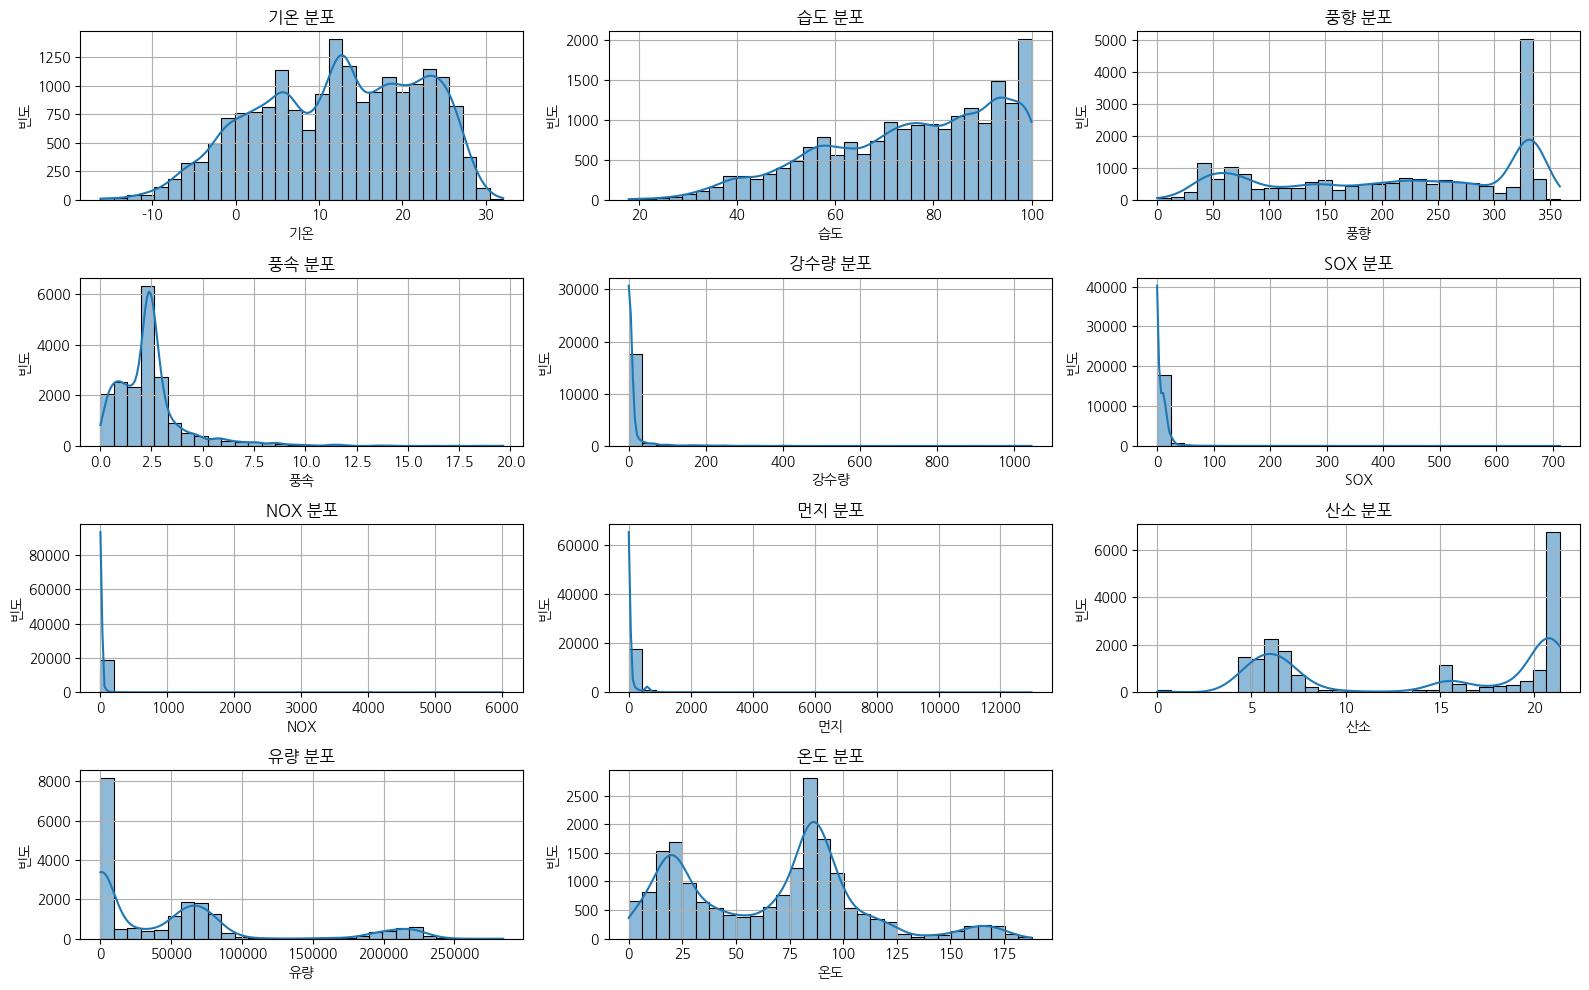

In [9]:
num_cols=df.select_dtypes(['int64','float64']).columns
plt.figure(figsize=(16, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f"{col} 분포")
    plt.xlabel(col)
    plt.ylabel("빈도")
    plt.grid(True)

plt.tight_layout()
plt.show()

### 상관관계

<Axes: >

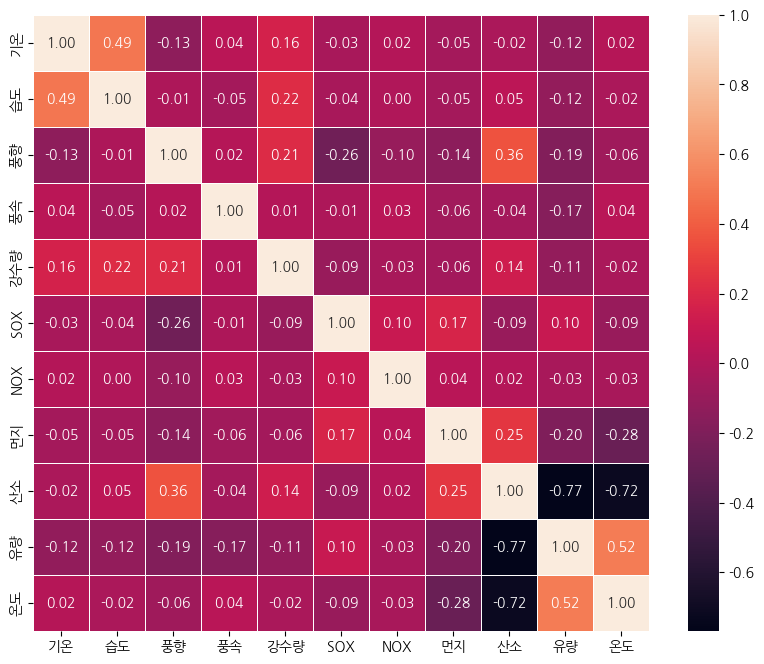

In [10]:
corr_matrix=df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,annot=True, fmt='.2f', square=True, linewidths=0.5)


In [11]:
target_corr = corr_matrix['NOX'].sort_values(ascending=False)
print("NOX와 다른 변수 간 상관계수:")
target_corr


NOX와 다른 변수 간 상관계수:


NOX    1.000000
SOX    0.103736
먼지     0.037687
풍속     0.034181
기온     0.018749
산소     0.017985
습도     0.003587
강수량   -0.029280
온도    -0.029752
유량    -0.034315
풍향    -0.104432
Name: NOX, dtype: float64

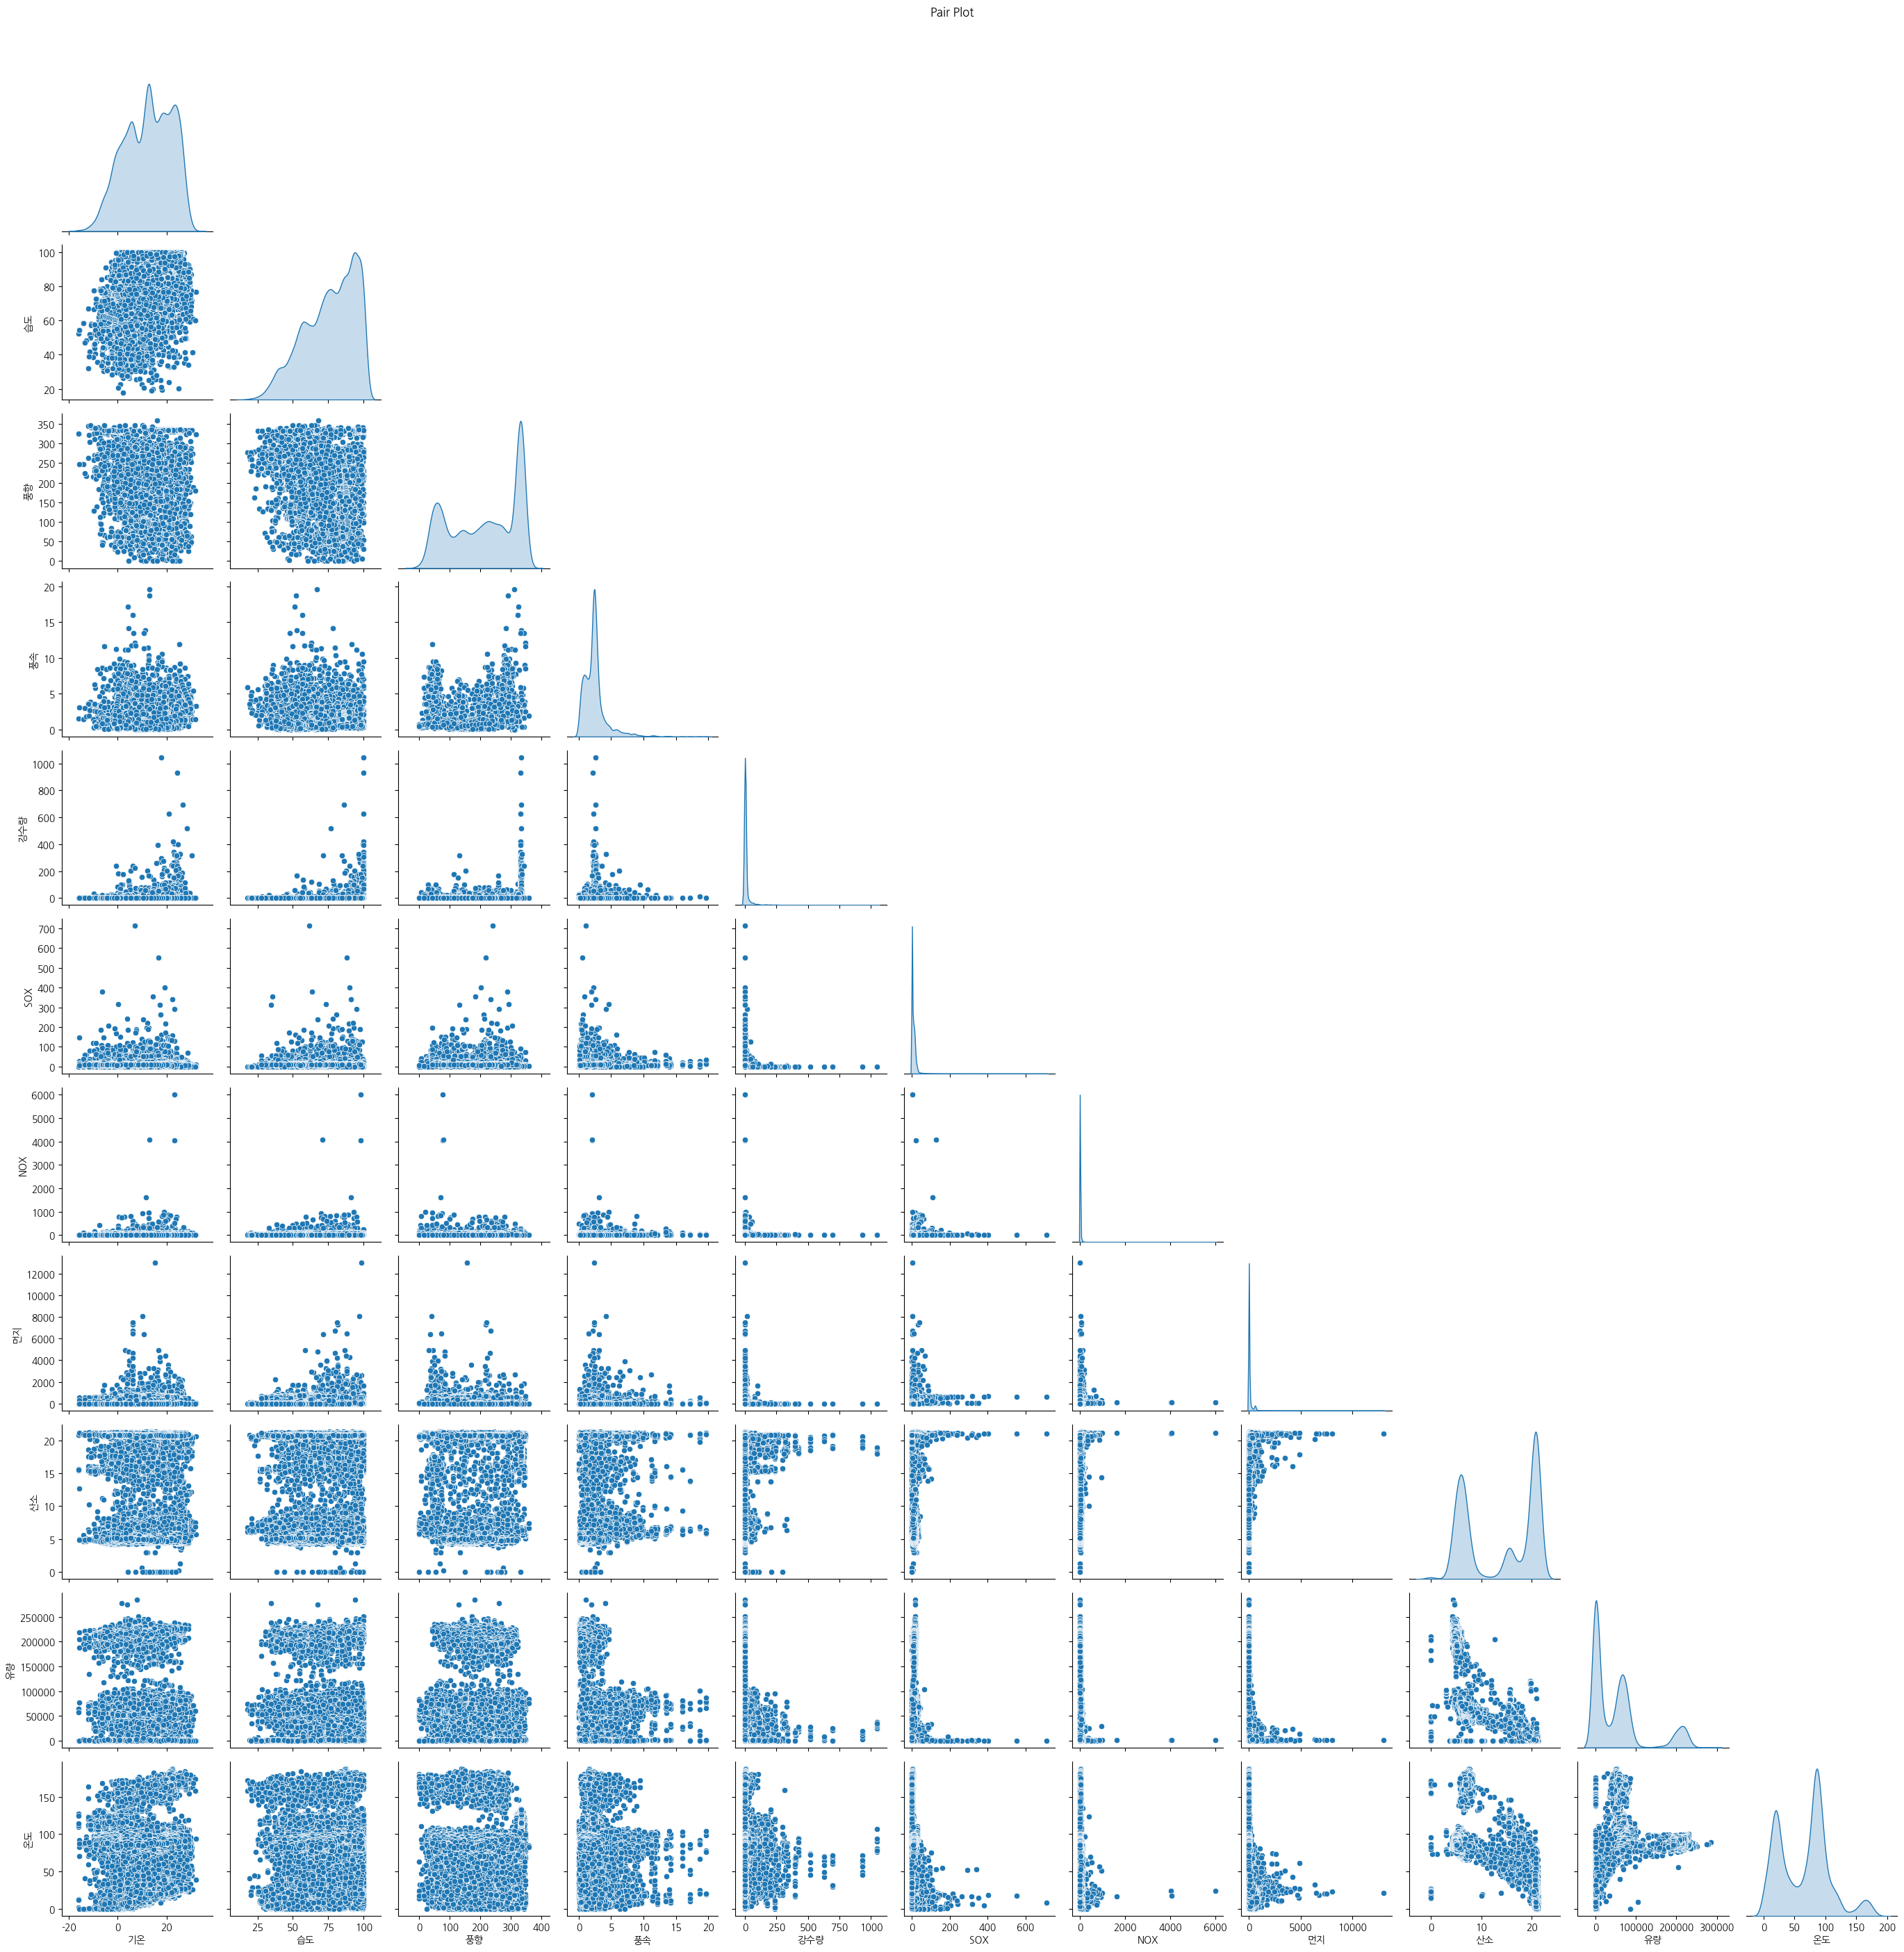

In [12]:
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle("Pair Plot", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# 상관성이 눈에 띄는 변수관계 없음

### 다중공선성 분석

#### VIF

In [14]:
num_cols

Index(['기온', '습도', '풍향', '풍속', '강수량', 'SOX', 'NOX', '먼지', '산소', '유량', '온도'], dtype='object')

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

input_vars =['기온', '습도', '풍향', '풍속', '강수량', 'SOX',  '먼지', '산소', '유량', '온도']

X=df[input_vars]
X_const = add_constant(X)

vif_df = pd.DataFrame()
vif_df["NOX"] = X_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

vif_df

,NOX,VIF
0,const,76.453874
1,기온,1.403445
2,습도,1.369105
3,풍향,1.488062
4,풍속,1.138169
5,강수량,1.118501
6,SOX,1.132703
7,먼지,1.189179
8,산소,5.162710
9,유량,2.971012


In [16]:
# 다중공선성이 대부분 약하며 독성이 있다고 볼수 있음
# vif에 의한 삭제 고려할만한 변수 없음

#### Mutual Information 기반 NOX 관련성 분석

In [17]:
# 두 변수 간 정보량 공유 정도를 나타내는 지표로, 선형/비선형 관계 모두 포착할 수 있는 비대칭 비선형 의존도 측정 도구

In [18]:
from sklearn.feature_selection import mutual_info_regression

df_mi = df[input_vars + ['NOX']].dropna()

X = df_mi[input_vars]
y = df_mi['NOX']

mi_scores = mutual_info_regression(X, y, random_state=0)


mi_df = pd.DataFrame({'변수': input_vars, 'Mutual Information': mi_scores})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)
mi_df.reset_index(drop=True, inplace=True)
mi_df


,변수,Mutual Information
0,산소,0.895779
1,유량,0.739248
2,먼지,0.720131
3,온도,0.714673
4,SOX,0.493543
5,풍향,0.338532
6,풍속,0.316681
7,기온,0.210647
8,습도,0.171320
9,강수량,0.106989


/var/folders/q9/1gz00szn5vz5011w8pll4_8h0000gn/T/ipykernel_1647/342948023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='Mutual Information', y='변수', palette='viridis')


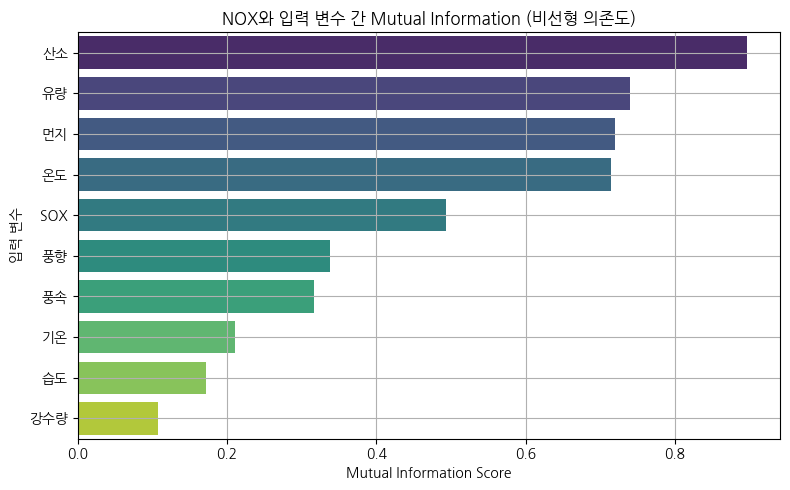

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=mi_df, x='Mutual Information', y='변수', palette='viridis')
plt.title('NOX와 입력 변수 간 Mutual Information (비선형 의존도)')
plt.xlabel('Mutual Information Score')
plt.ylabel('입력 변수')
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
# 산소 농도, 유량, 먼지 농도, 온도 등이 높은 MI 점수를 기록하며 예측력 있는 변수
# 위 변수들 활용해 파생변수 생성 고려해볼만 함

### 변수 변환 그래프(로그 변환, 표준화 )

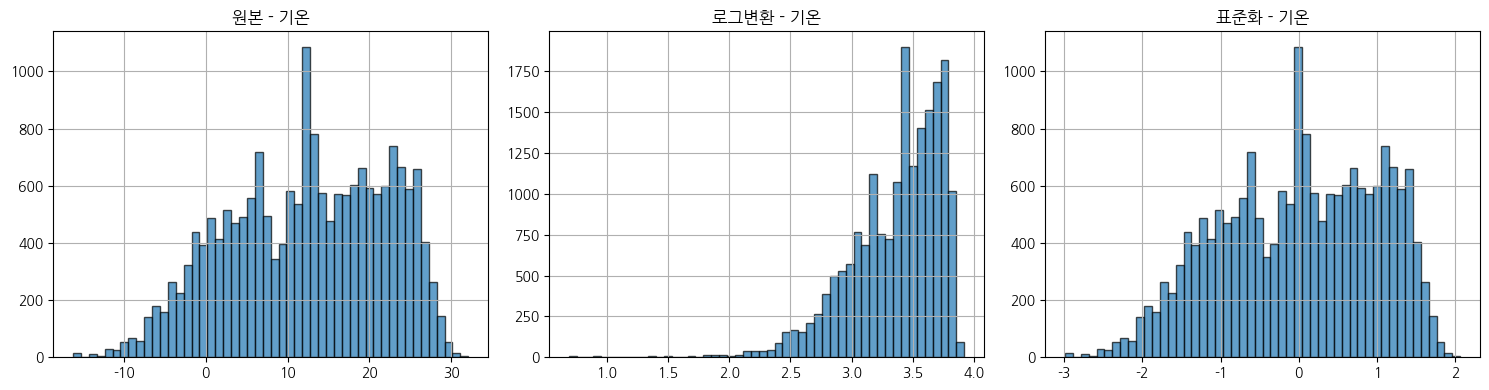

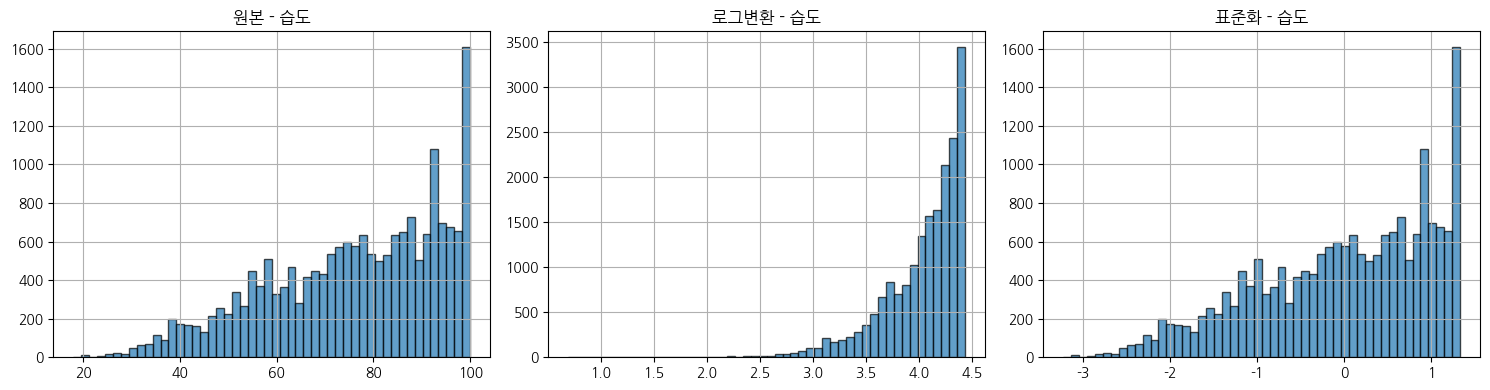

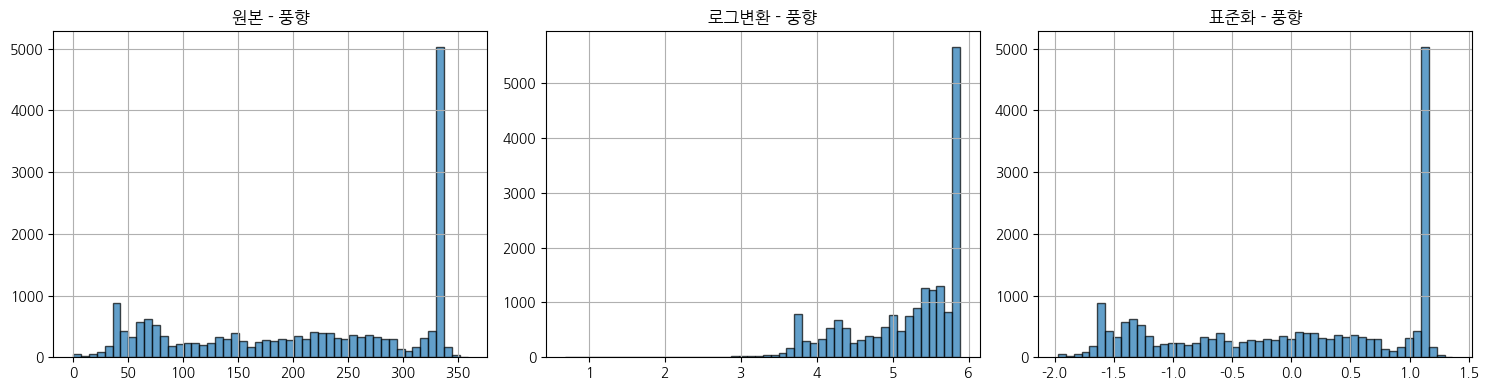

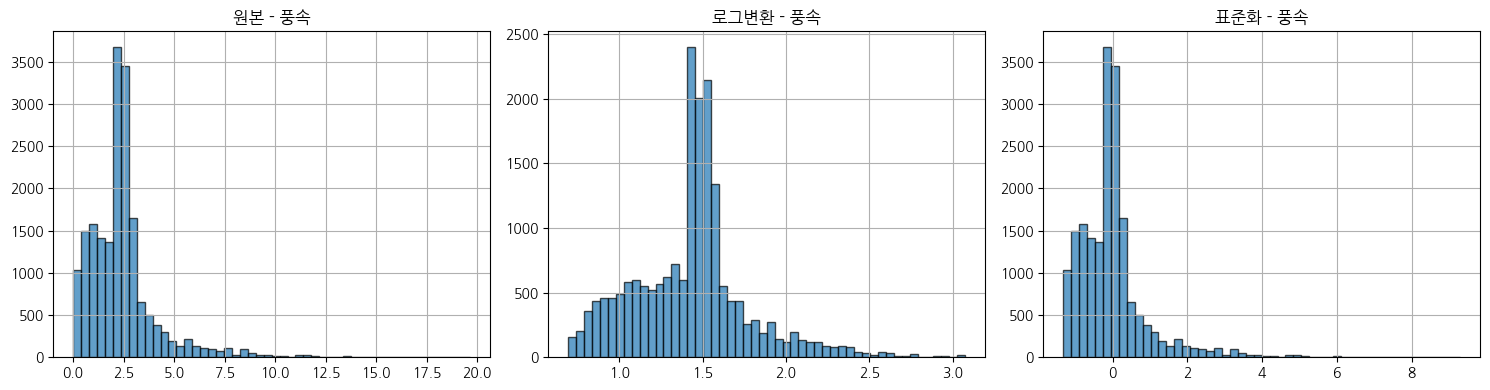

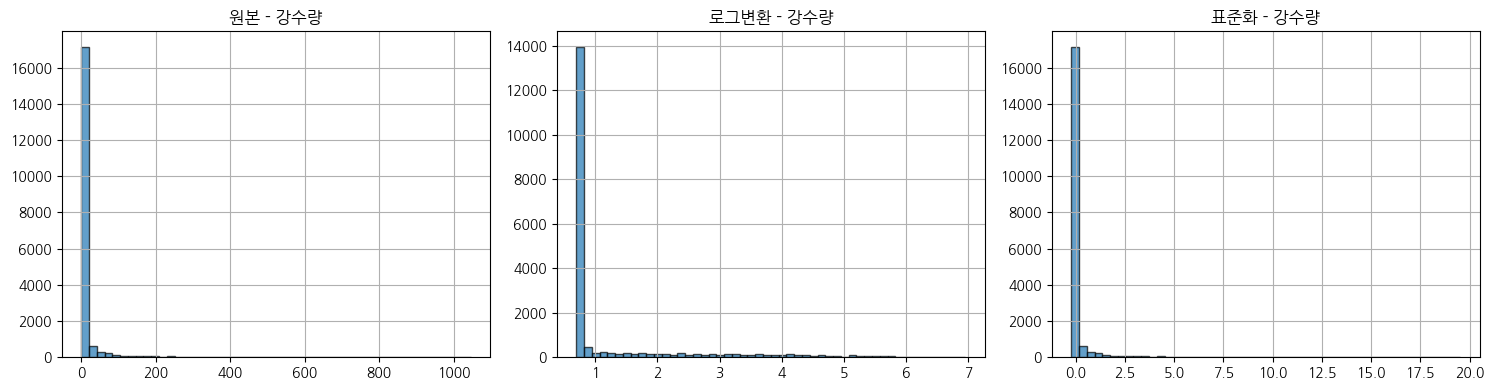

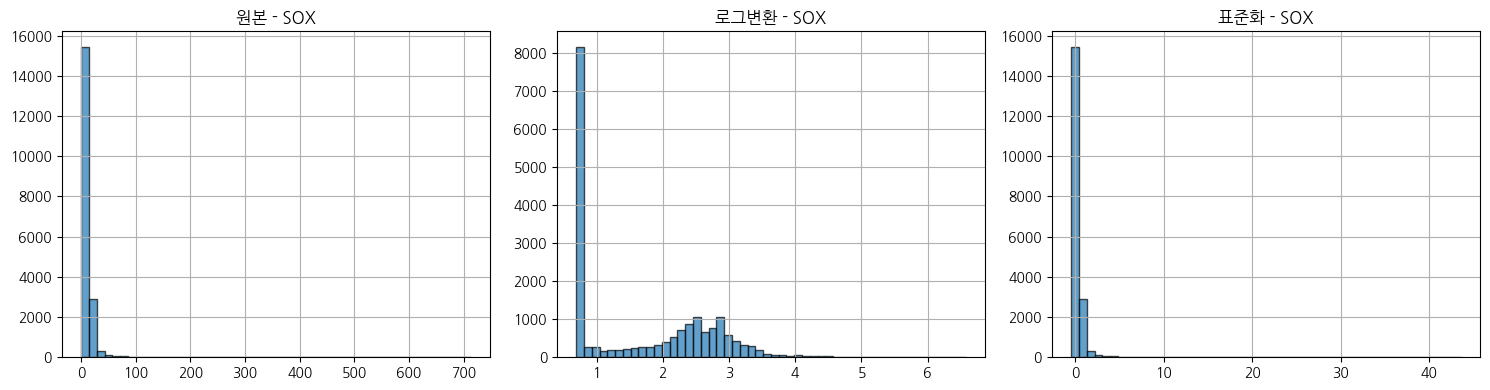

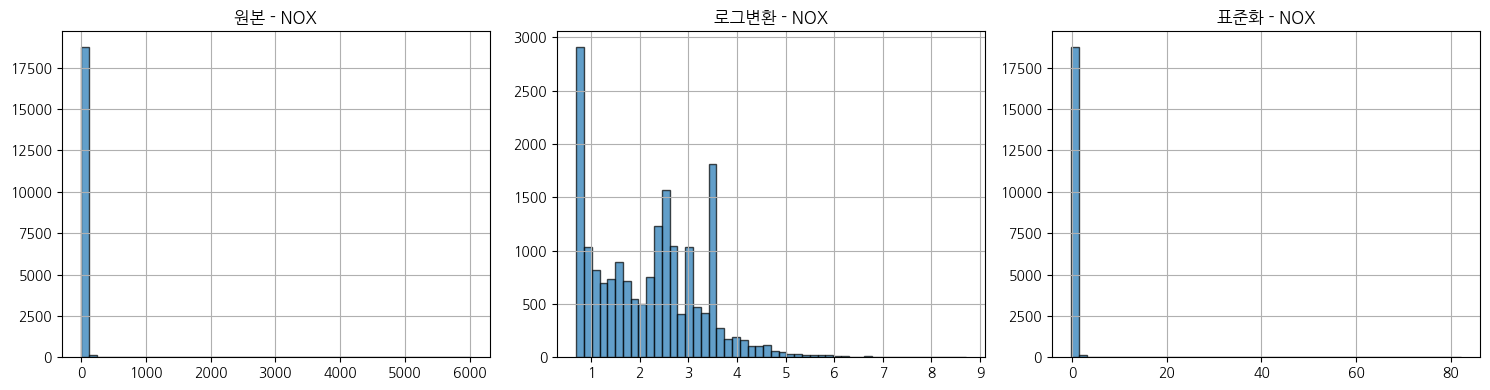

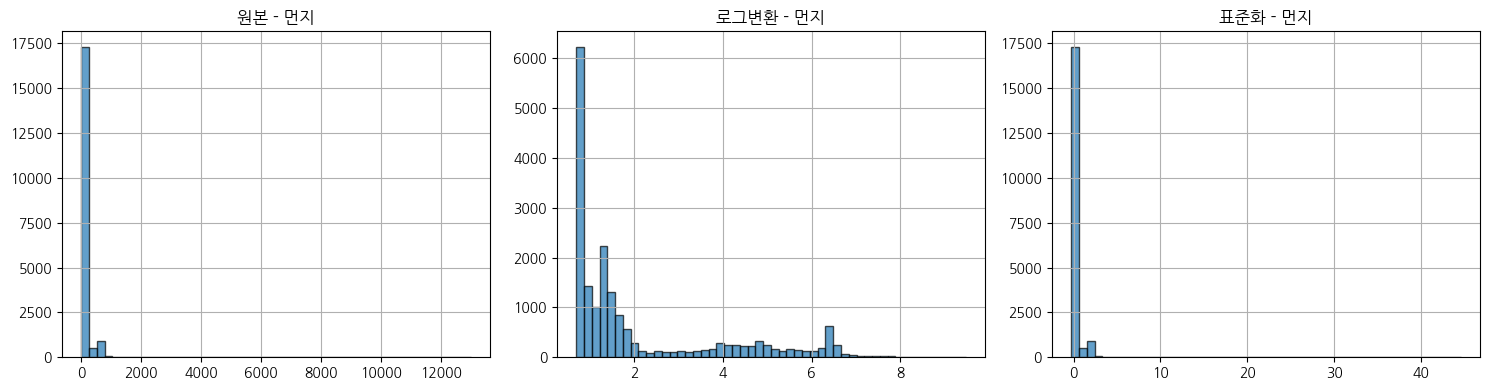

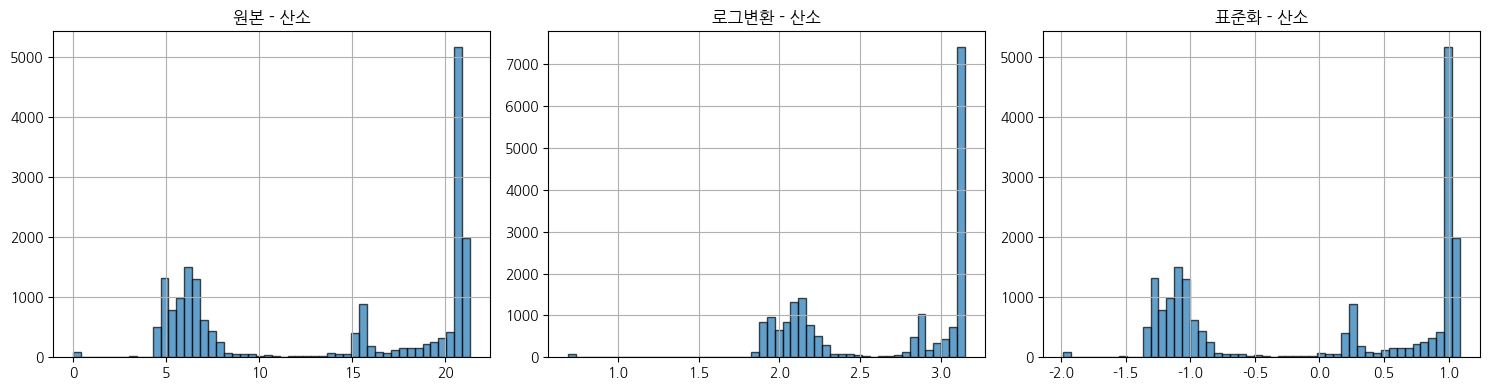

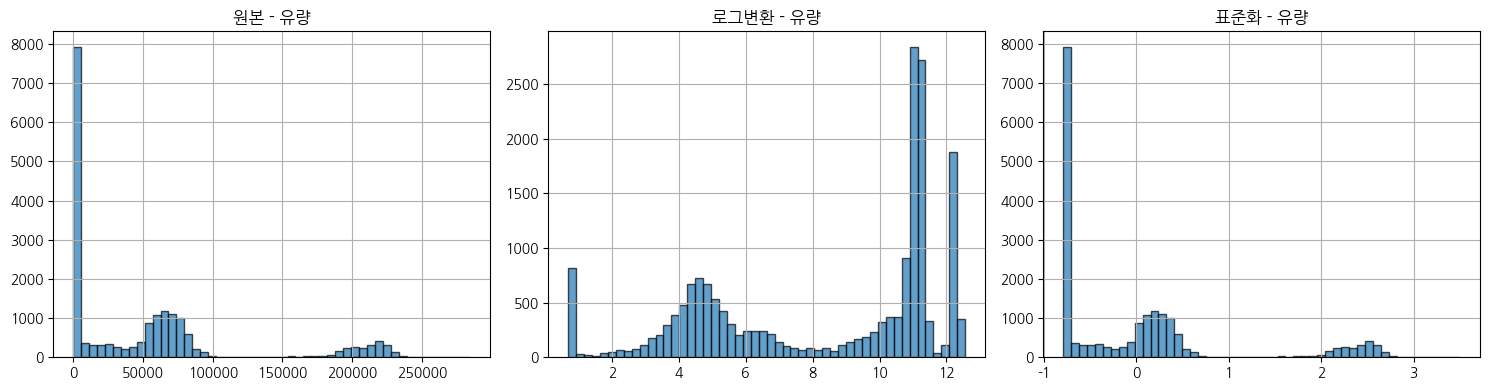

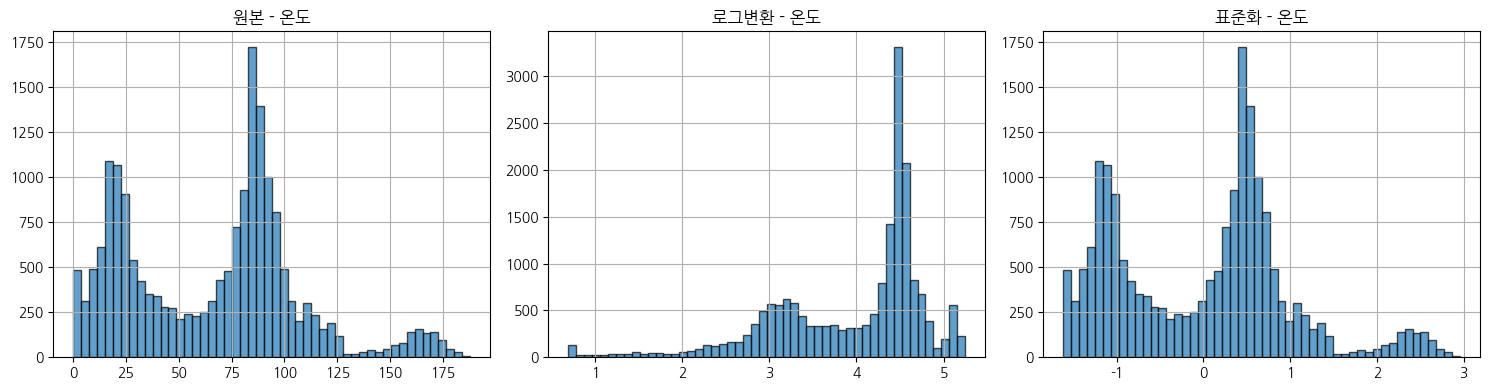

In [21]:
from sklearn.preprocessing import StandardScaler
num_cols = df.select_dtypes(['int64', 'float64']).columns.tolist()
df_num = df[num_cols].dropna()
df_log = np.log1p(df_num - df_num.min() + 1)


# 표준화(Z-score scaling)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=num_cols)

def plot_distributions(data_dict, variables, bins=50):
    for var in variables:
        plt.figure(figsize=(15, 4))
        for i, (label, df_) in enumerate(data_dict.items(), 1):
            plt.subplot(1, 3, i)
            plt.hist(df_[var], bins=bins, alpha=0.7, edgecolor='black')
            plt.title(f"{label} - {var}")
            plt.grid(True)
        plt.tight_layout()
        plt.show()

key_vars = num_cols 


data_versions = {
    "원본": df_num,
    "로그변환": df_log,
    "표준화": df_scaled
}

plot_distributions(data_versions, key_vars)

### 사업소별 배출물질농도 통계적 차이

| 구분        | 분석 내용                       | 방법                       |
| --------- | --------------------------- | ------------------------ |
| 📊 분포 분석  | 각 사업소의 NOX, SOX 등 주요 변수의 분포 | 히스토그램, 박스플롯, KDE         |
| 📈 시계열 분석 | NOX의 시간 흐름별 트렌드 및 계절성       | 라인플롯, 롤링 평균              |
| 📉 이상치 탐색 | 사업소별 이상값 패턴 비교              | Boxplot, IQR 또는 z-score  |
| 📎 변수간 관계 | 사업소별 NOX vs 유량, 온도 등 상관성    | 산점도, 피어슨/MI              |
| 🧪 통계 검정  | **사업소 간 NOX 평균 차이 유의한가?**   | ANOVA, Tukey HSD (사후 검정) |


#### 사업소별 변수 통계량 및 시각화

In [22]:
df.pivot_table(index='사업소',values=['SOX','NOX','먼지','산소','유량',	'온도'],aggfunc='mean').style.background_gradient()

,NOX,SOX,먼지,산소,온도,유량
사업소,,,,,,
분당,4.753118,0.000000,0.000000,18.864252,60.206184,19270.756106
삼천포,29.089659,13.410373,112.503841,11.197104,65.976257,46378.873196
여수,15.118085,2.698003,31.878078,12.121108,65.910951,43487.559911
영동,42.119265,1.977681,13.013687,10.362114,125.948454,37805.241997
영흥,7.811211,14.182877,174.366978,12.147975,55.306230,112264.466287


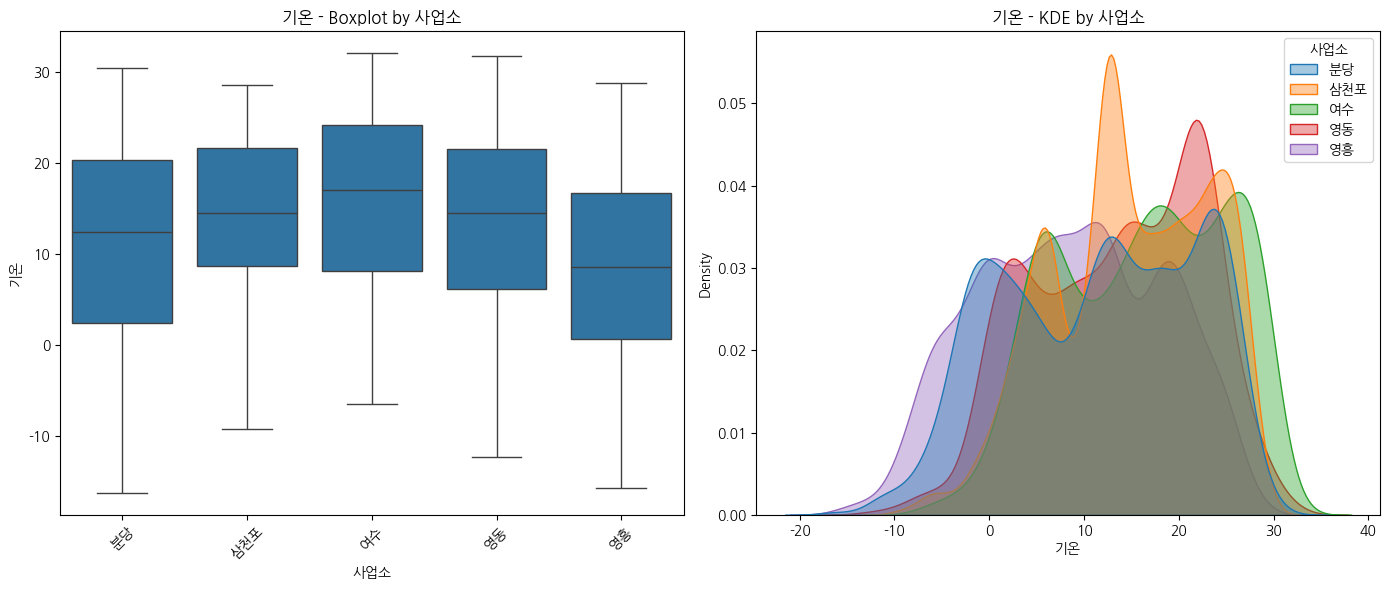

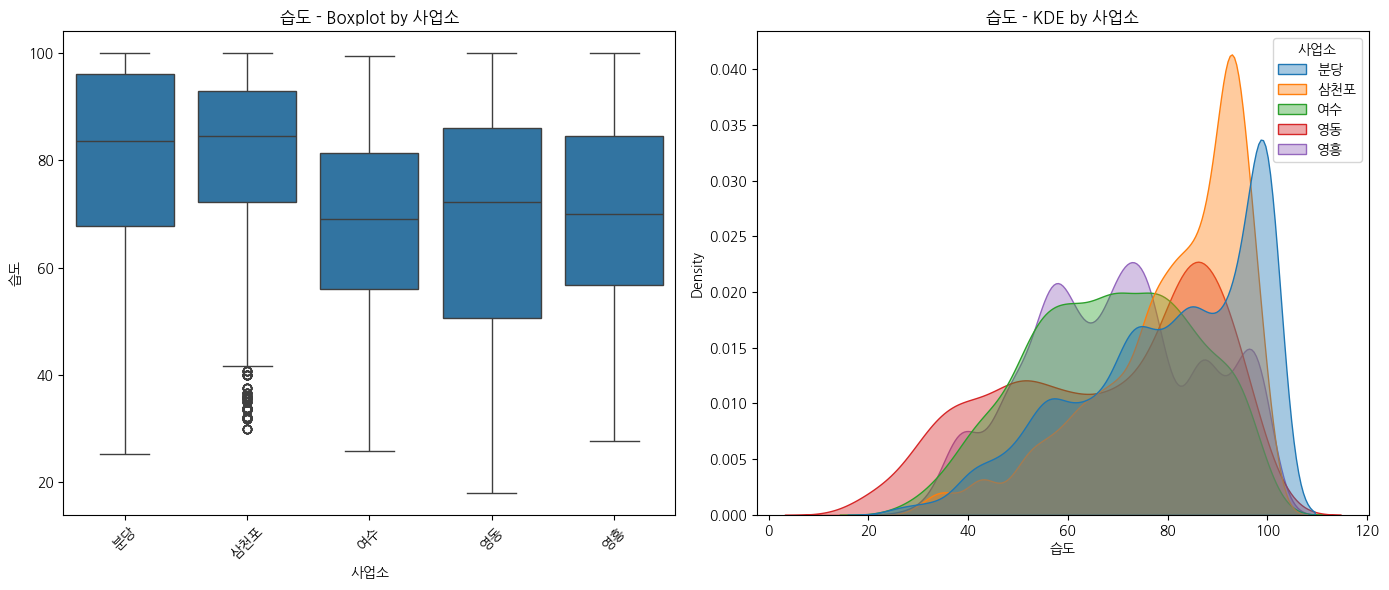

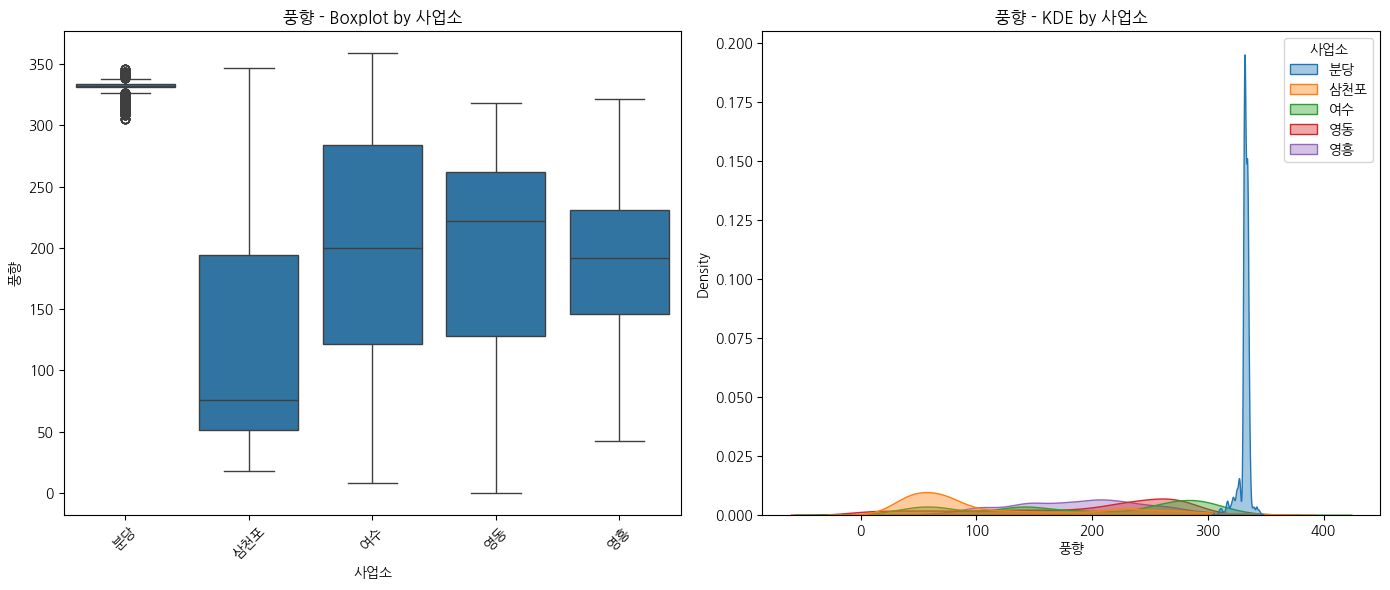

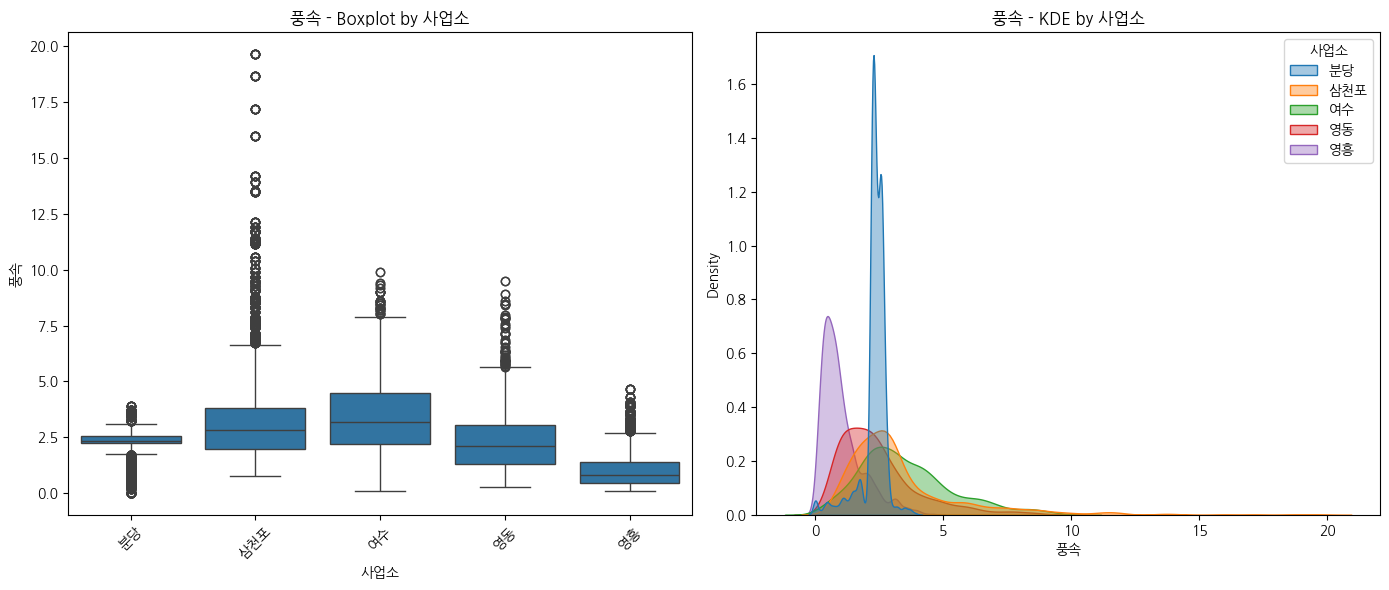

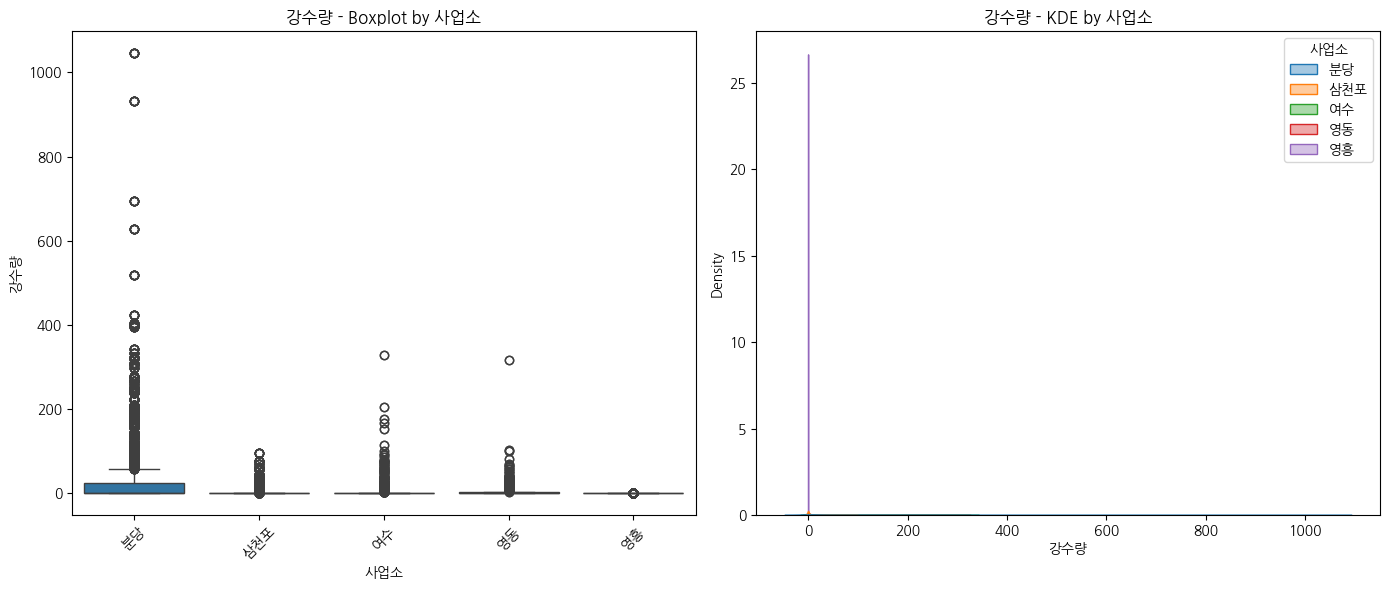

/var/folders/q9/1gz00szn5vz5011w8pll4_8h0000gn/T/ipykernel_1647/2855735986.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue='사업소', fill=True, common_norm=False, alpha=0.4, ax=axes[1])


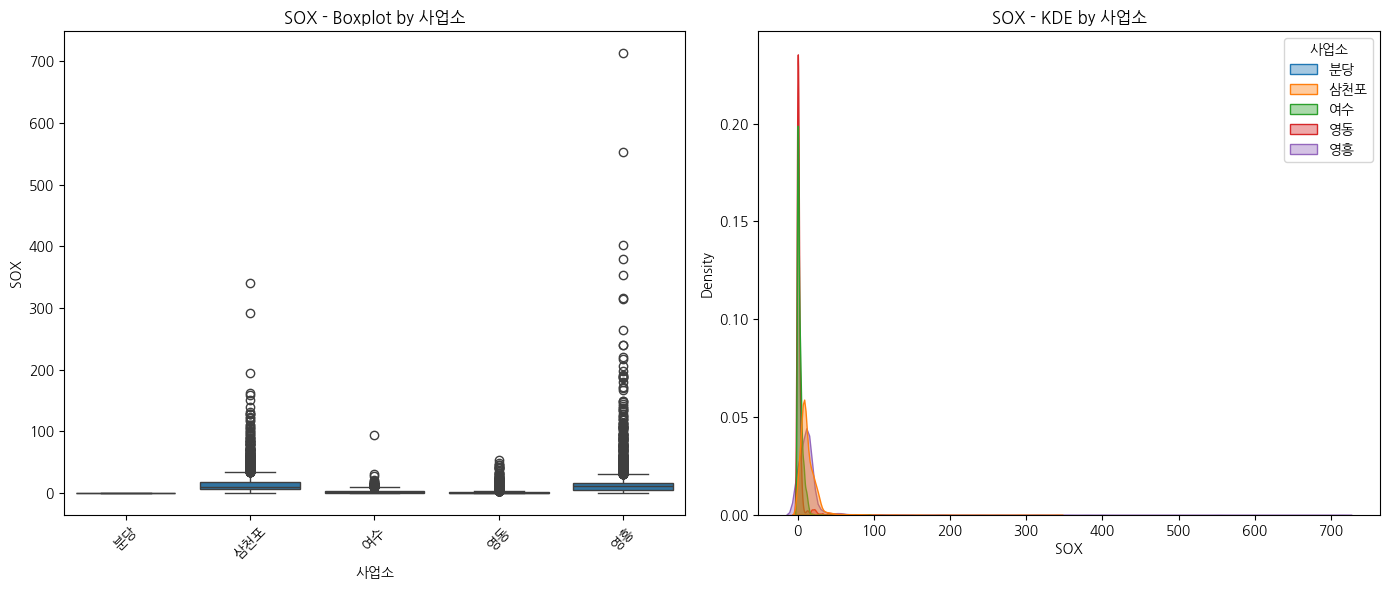

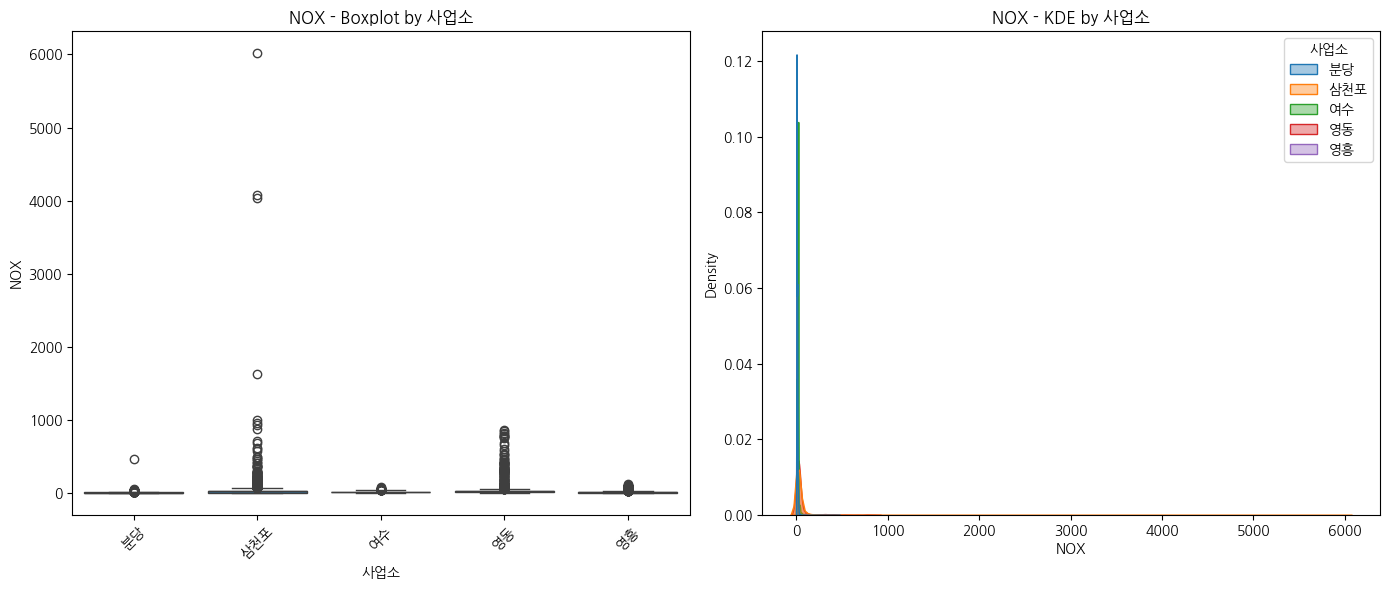

/var/folders/q9/1gz00szn5vz5011w8pll4_8h0000gn/T/ipykernel_1647/2855735986.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue='사업소', fill=True, common_norm=False, alpha=0.4, ax=axes[1])


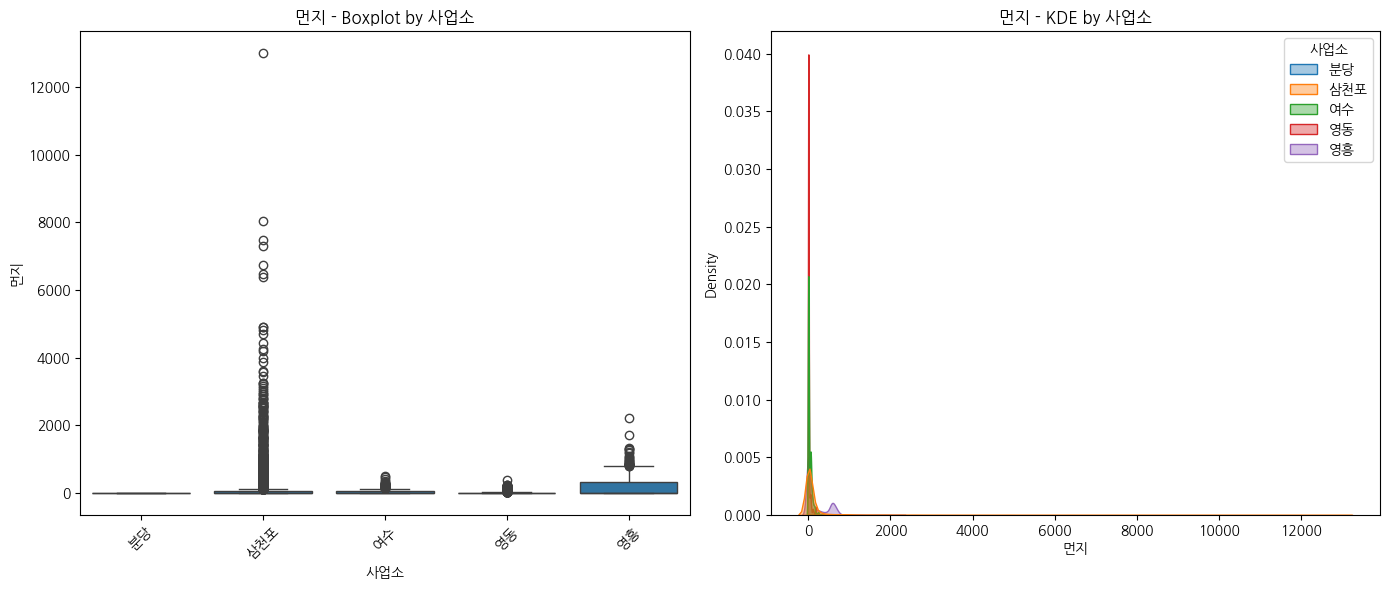

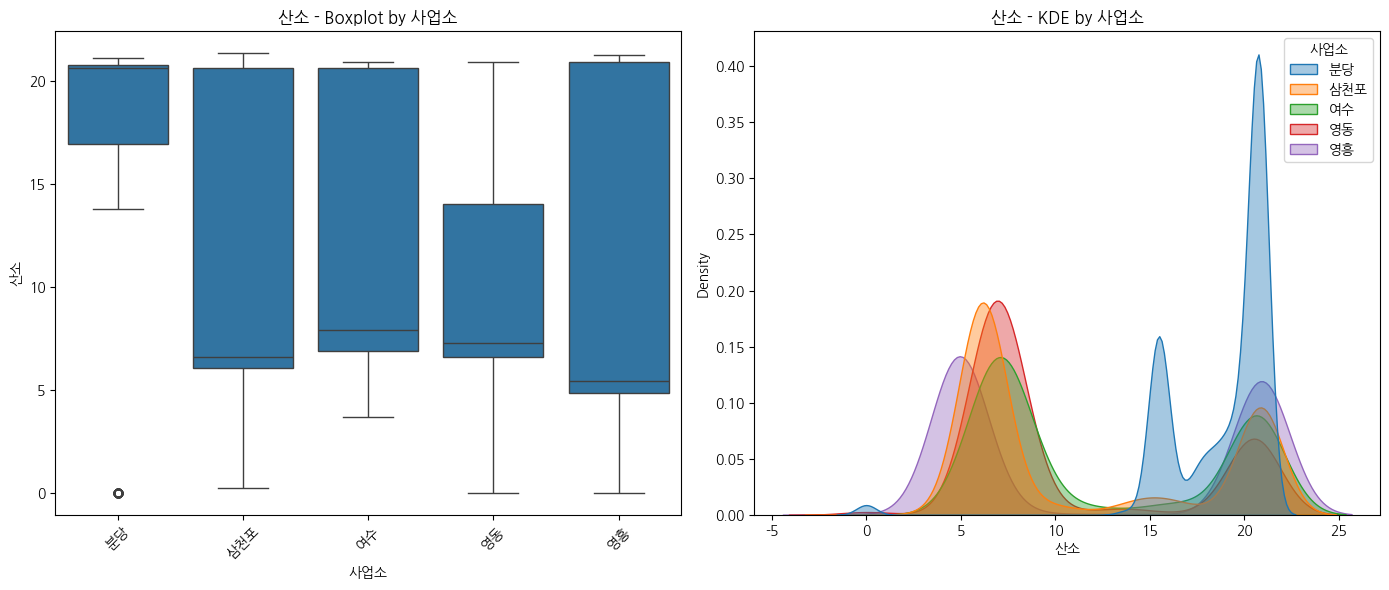

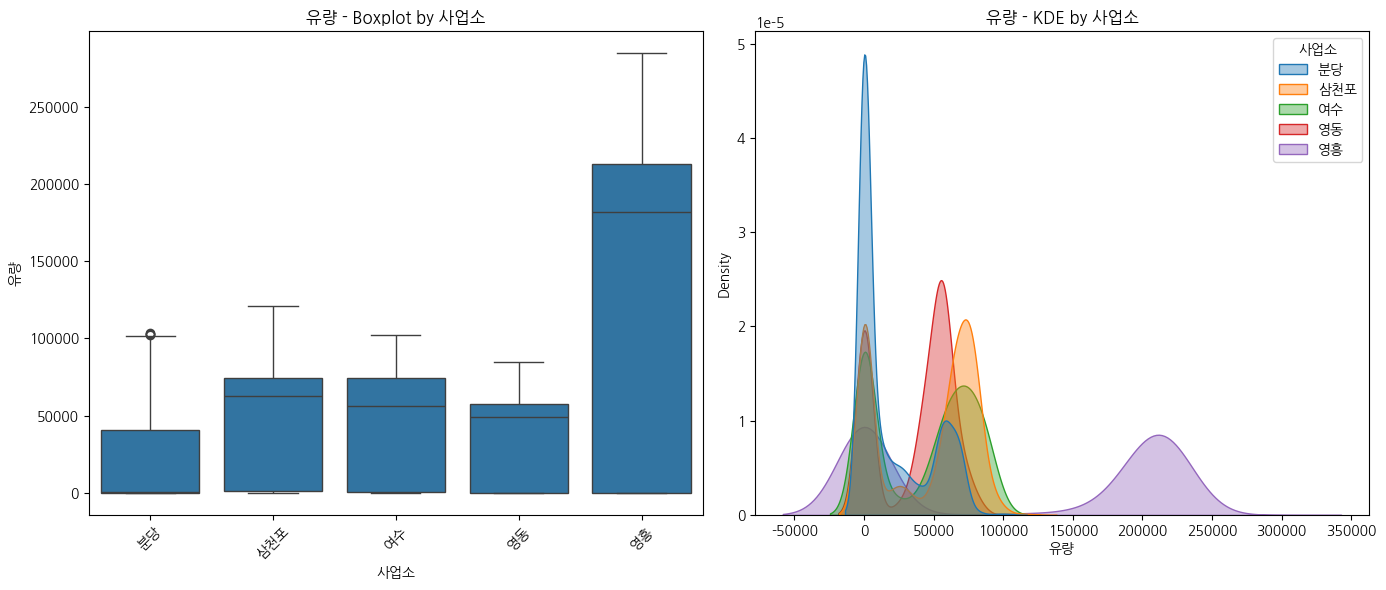

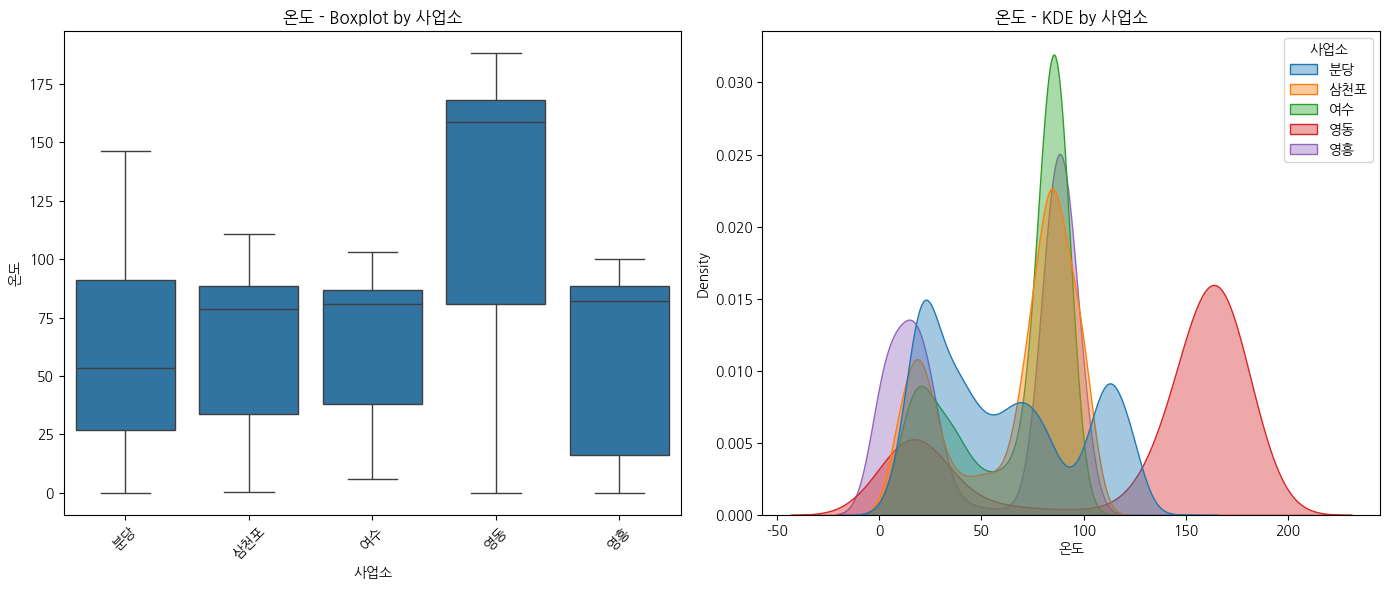

In [23]:
사업소_list = df['사업소'].unique()


for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))  
    
    # Boxplot
    sns.boxplot(x='사업소', y=col, data=df, ax=axes[0])
    axes[0].set_title(f'{col} - Boxplot by 사업소')
    axes[0].set_xlabel('사업소')
    axes[0].set_ylabel(col)
    axes[0].tick_params(axis='x', rotation=45)
    
    # KDE Plot
    sns.kdeplot(data=df, x=col, hue='사업소', fill=True, common_norm=False, alpha=0.4, ax=axes[1])
    axes[1].set_title(f'{col} - KDE by 사업소')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Density')

    plt.tight_layout()
    plt.show()


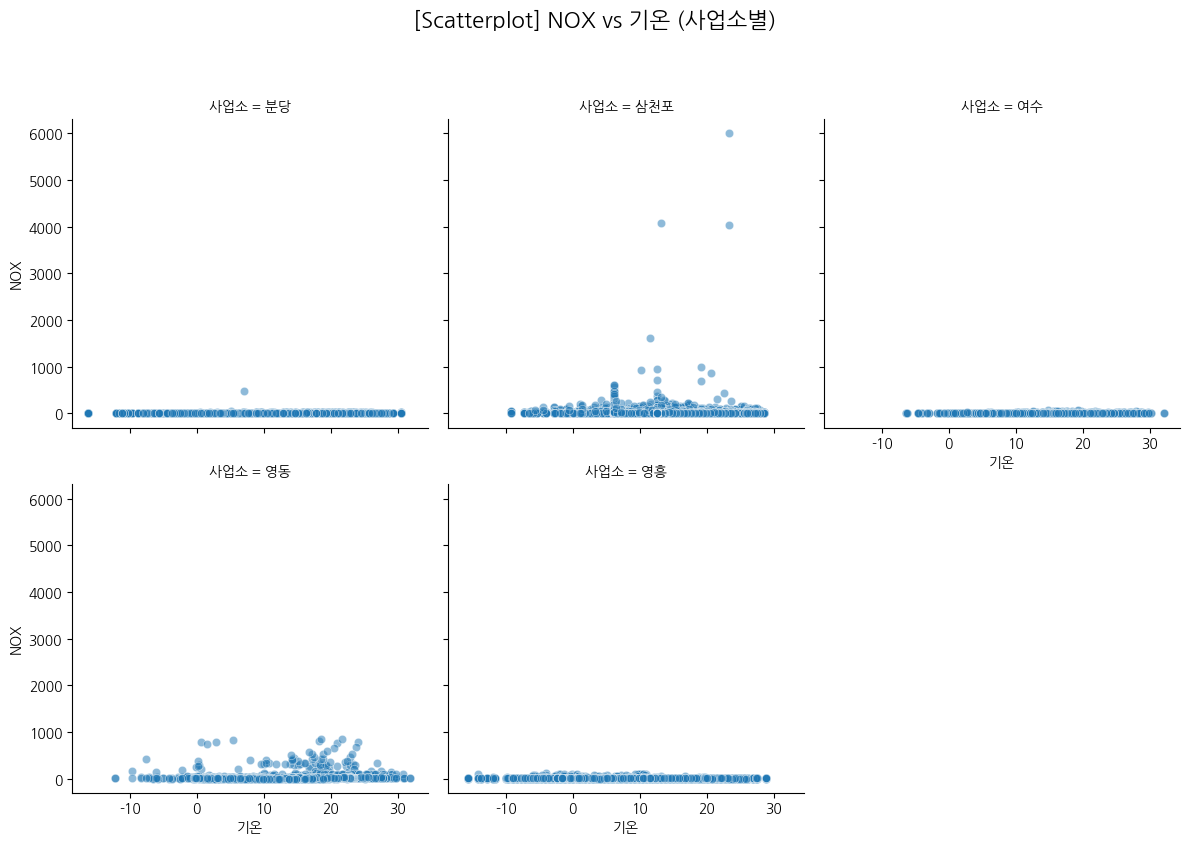

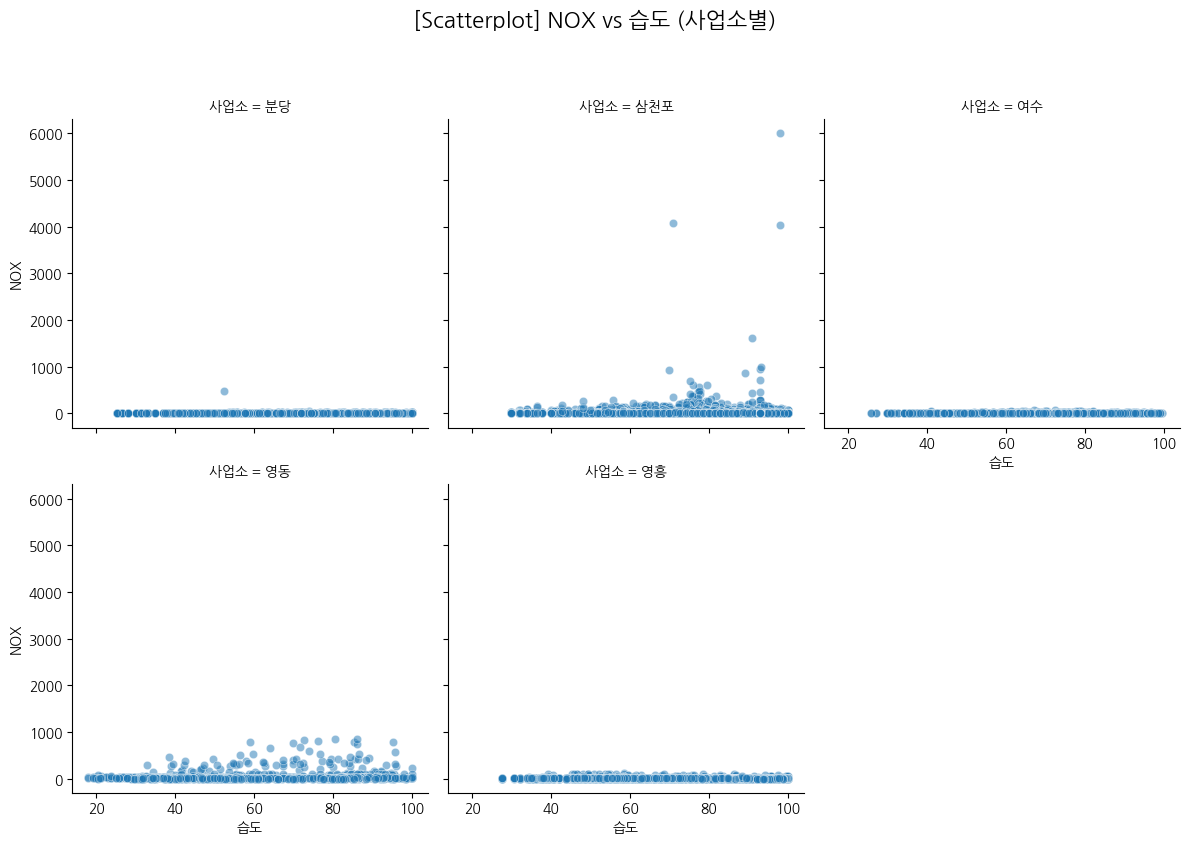

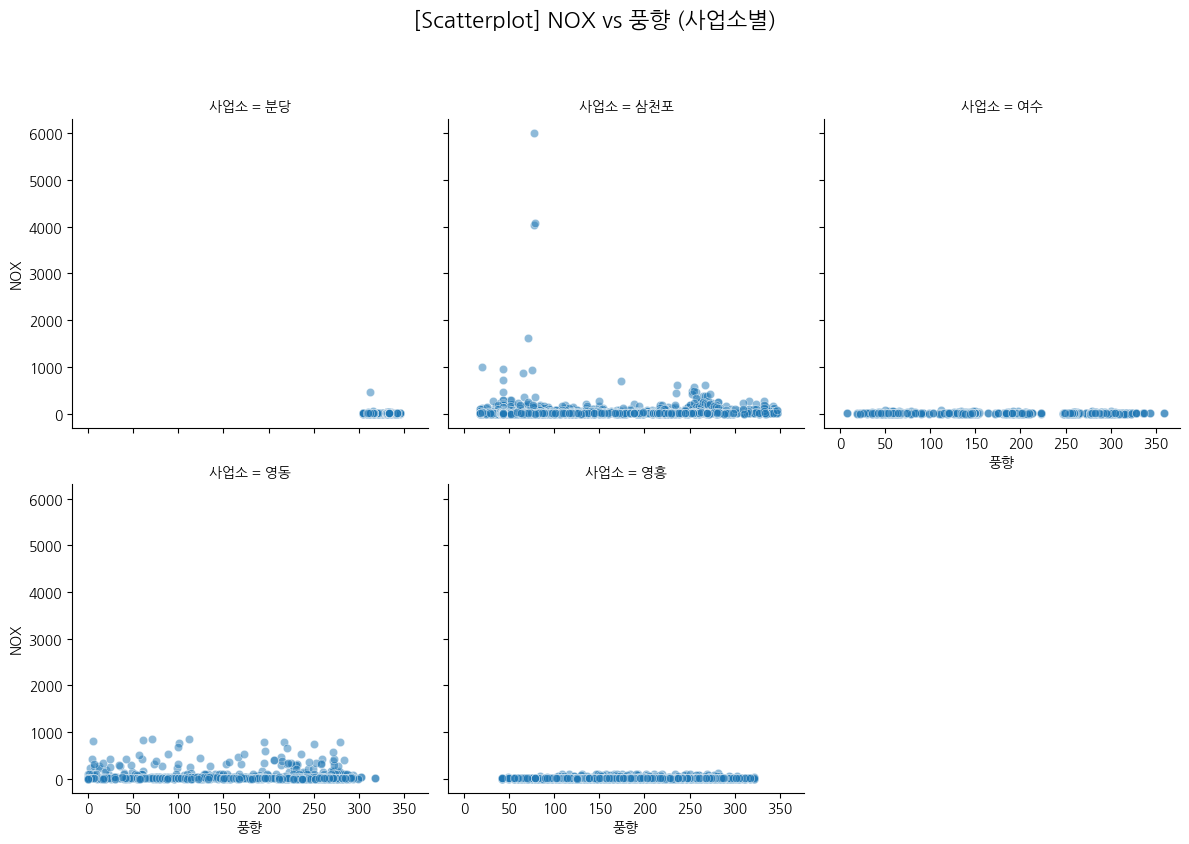

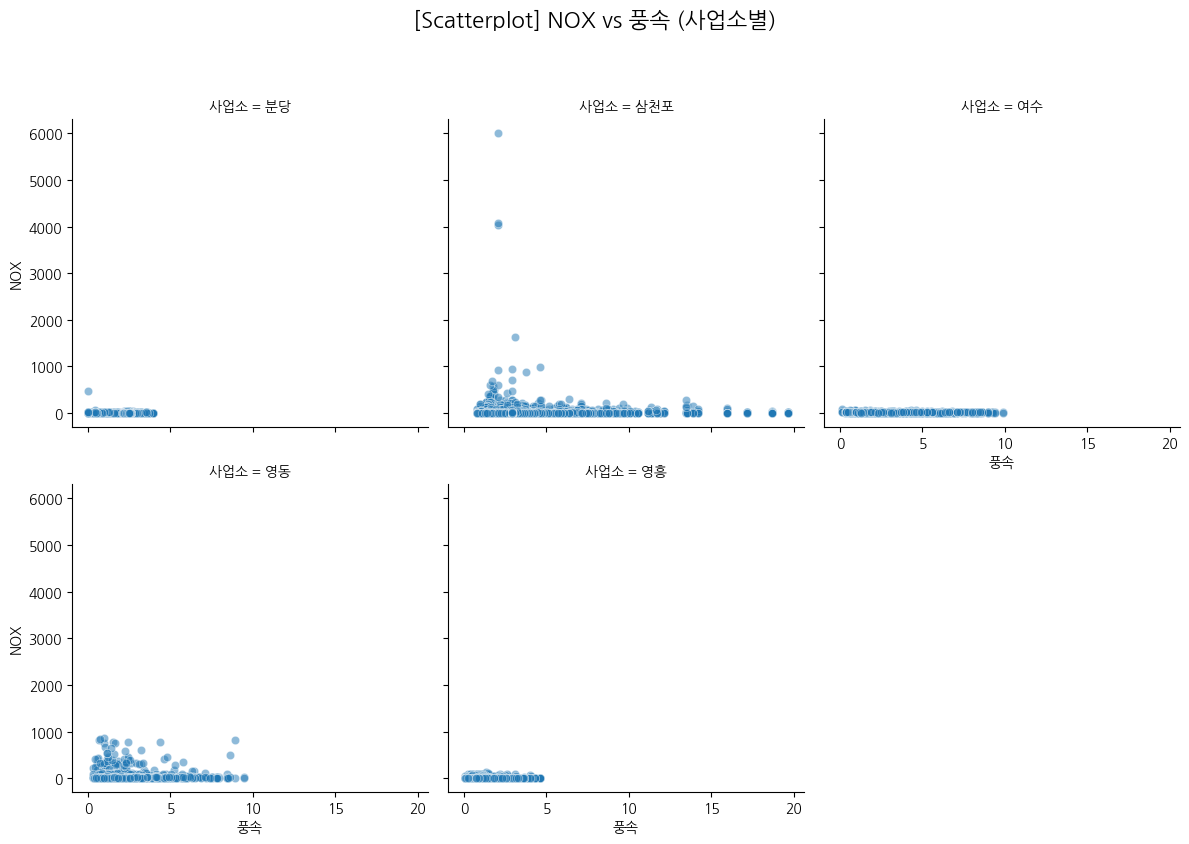

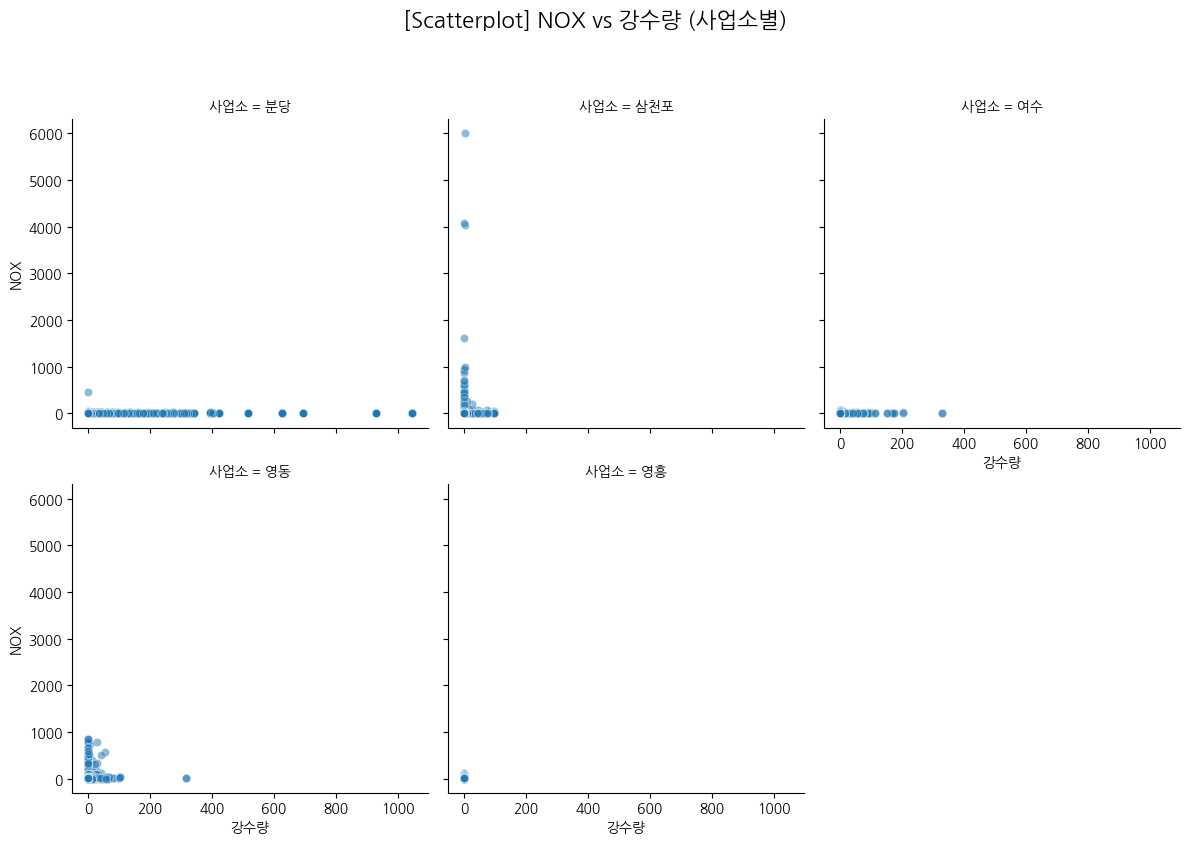

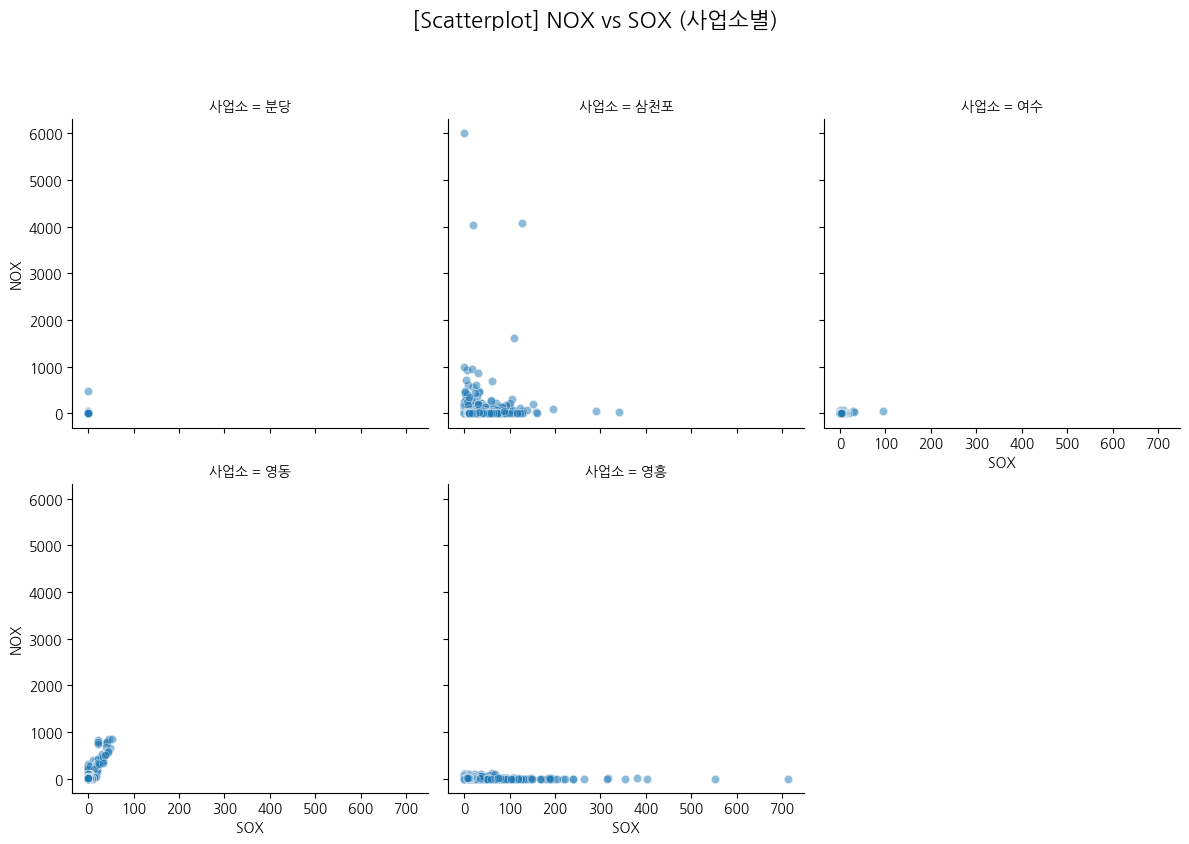

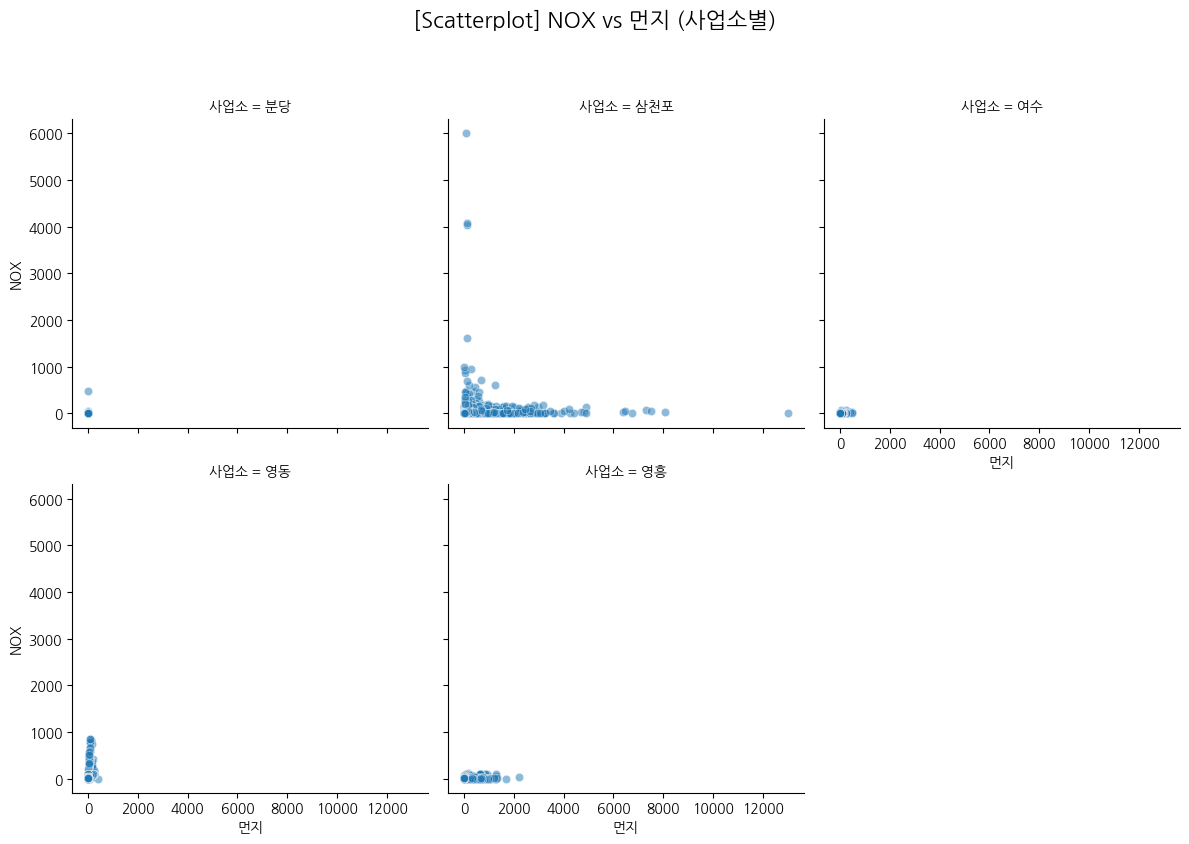

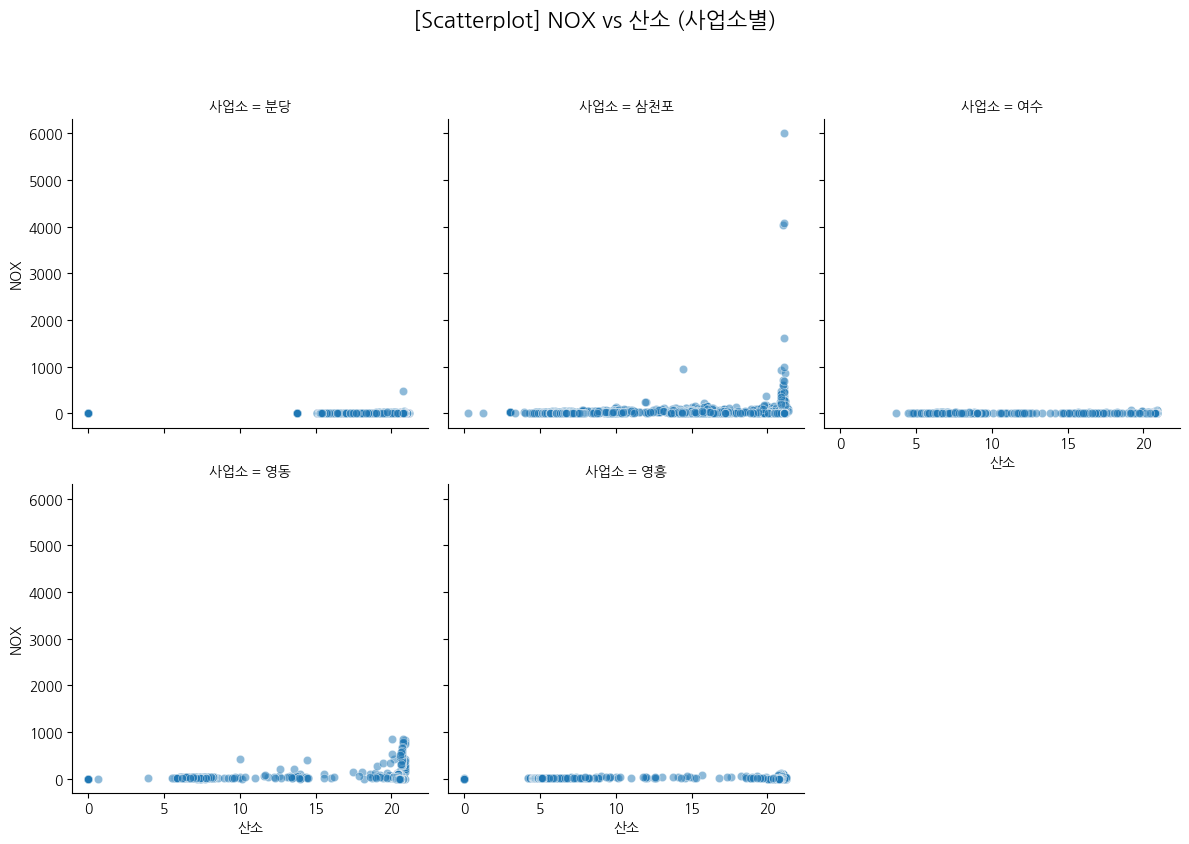

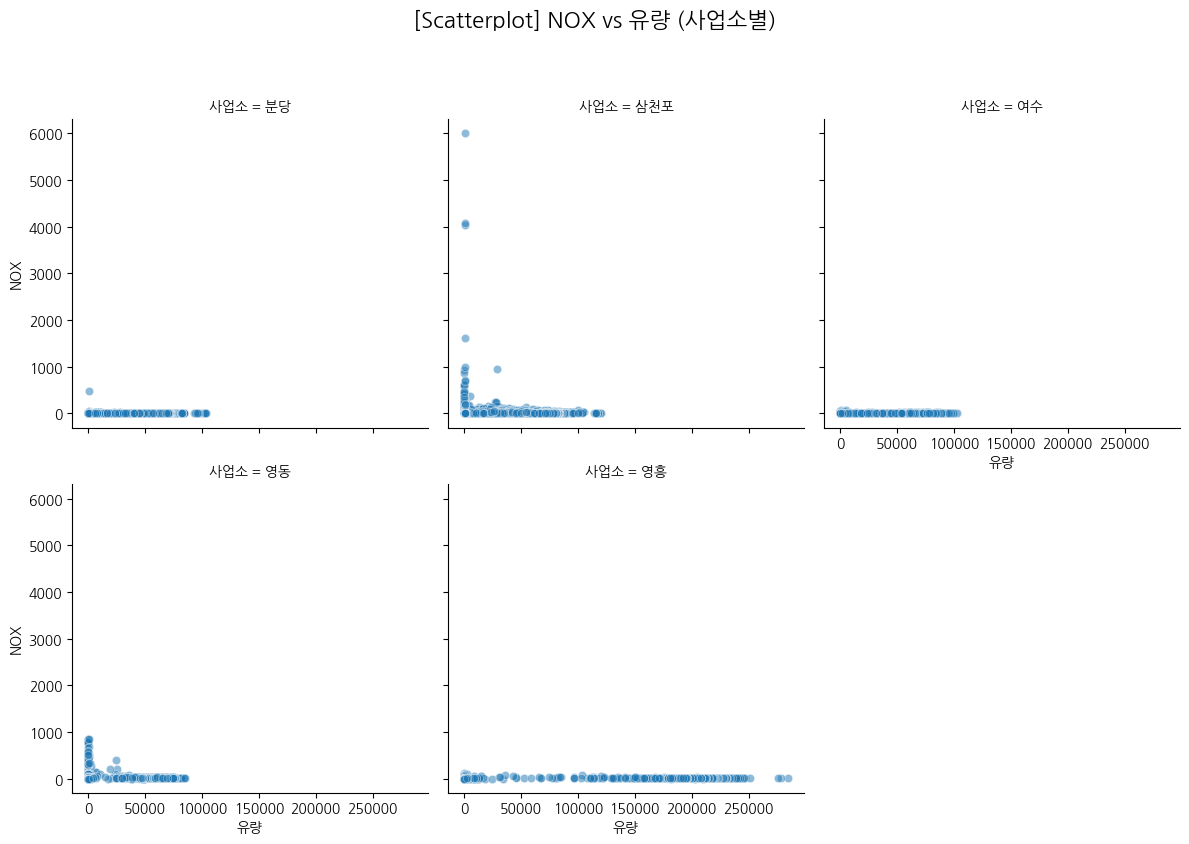

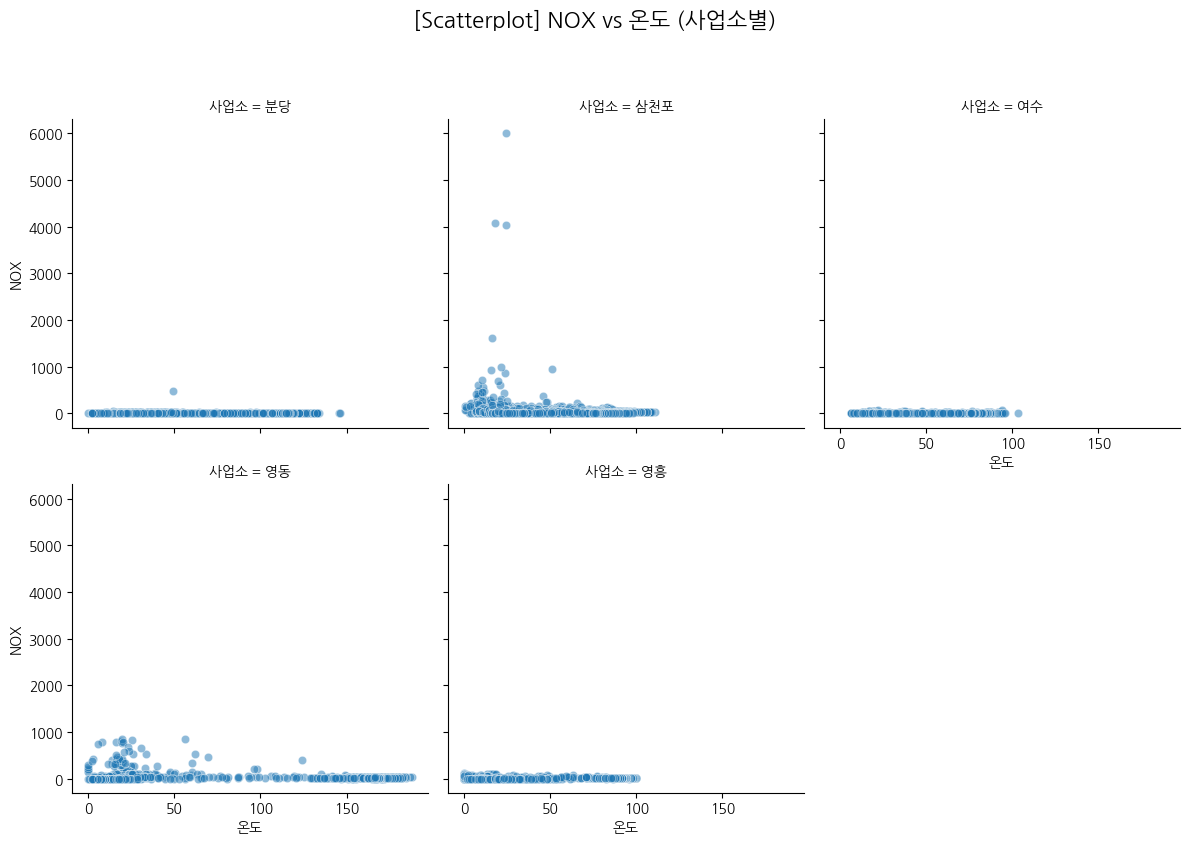

In [24]:

compare_vars =['기온', '습도', '풍향', '풍속', '강수량', 'SOX',  '먼지', '산소', '유량', '온도']

for var in compare_vars:
    g = sns.FacetGrid(df, col='사업소', col_wrap=3, height=4)
    g.map_dataframe(sns.scatterplot, x=var, y='NOX', alpha=0.5)
    g.fig.suptitle(f"[Scatterplot] NOX vs {var} (사업소별)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

In [25]:
result_list = []

for name, group in df.groupby('사업소'):
    corrs = {}
    for var in compare_vars:
        if group[[var, 'NOX']].dropna().shape[0] > 0:
            corrs[var] = group[[var, 'NOX']].corr().iloc[0, 1]
    result_list.append(pd.Series(corrs, name=name))

corr_df = pd.DataFrame(result_list)
print("사업소별 NOX 상관계수:\n")
display(corr_df.style.background_gradient(cmap='coolwarm', axis=None))

사업소별 NOX 상관계수:



,기온,습도,풍향,풍속,강수량,SOX,먼지,산소,유량,온도
분당,-0.115704,-0.079957,-0.109247,-0.115377,-0.002982,nan,nan,-0.172717,0.282786,0.269910
삼천포,-0.030337,0.001452,0.005090,-0.019617,-0.018806,0.121511,0.044084,0.137096,-0.127805,-0.129883
여수,0.077235,0.087126,-0.091729,-0.078227,0.031376,0.300463,-0.058114,-0.491020,0.460150,0.445072
영동,0.065371,0.040536,-0.081478,-0.034795,0.001046,0.852005,0.487165,0.385906,-0.316119,-0.359775
영흥,-0.087562,-0.036326,0.021423,0.016454,-0.007712,-0.030922,-0.266436,-0.311759,0.303893,0.299762


In [26]:
# 상관관계 사업소별로 상이함
# 특히, 산소, 유량, 온도는 일부 사업소에서 중간 이상의 상관성을 보이며 예측 모델링 시 중요 변수로 활용 가능성이 있
# 동일한 변수라도 NOX와 관계 방향이 다름 → 개별적 모델 학습 필요 가능성
# 영동: SOX, 산소 / 여수: 유량, 온도 / 영흥: 온도, 유량 -> 사업소 맞춤형 변수 선정 가능


In [27]:
mi_result = {}

for name, group in df.groupby('사업소'):
    clean = group[compare_vars + ['NOX']].dropna()
    if len(clean) > 0:
        X = clean[compare_vars]
        y = clean['NOX']
        mi = mutual_info_regression(X, y, random_state=42)
        mi_result[name] = dict(zip(compare_vars, mi))

mi_df = pd.DataFrame(mi_result).T
print("사업소별 NOX Mutual Information:\n")
display(mi_df.style.background_gradient(cmap='YlOrBr', axis=None))

사업소별 NOX Mutual Information:



,기온,습도,풍향,풍속,강수량,SOX,먼지,산소,유량,온도
분당,0.277264,0.131037,0.245009,0.208777,0.097196,0.000937,0.000000,0.833295,0.791653,0.615092
삼천포,0.182249,0.115218,0.111713,0.107251,0.037849,0.381187,0.784022,0.546465,0.500477,0.706063
여수,0.126545,0.025808,0.021196,0.003977,0.000000,0.398943,0.743852,0.808564,0.671429,0.704926
영동,0.111066,0.045864,0.000000,0.035084,0.014088,0.457254,0.977583,0.653901,0.560315,0.634295
영흥,0.076940,0.050184,0.017851,0.000000,0.017098,0.809412,0.835099,0.900798,0.791105,0.923434


#### 정규성 검정 및 사업소별 nox 차이 유의미성 검정

In [28]:
from scipy.stats import shapiro

print("📌 사업소별 NOX 정규성 검정 (Shapiro-Wilk):\n")
for name, group in df.groupby('사업소'):
    stat, p = shapiro(group['NOX'].dropna())
    result = "정규" if p > 0.05 else "비정규"
    print(f"{name} → p-value: {p:.4f} → {result}")

📌 사업소별 NOX 정규성 검정 (Shapiro-Wilk):

분당 → p-value: 0.0000 → 비정규
삼천포 → p-value: 0.0000 → 비정규
여수 → p-value: 0.0000 → 비정규
영동 → p-value: 0.0000 → 비정규
영흥 → p-value: 0.0000 → 비정규


/Users/leehyunjoo/Library/Python/3.9/lib/python/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5848.
  res = hypotest_fun_out(*samples, **kwds)


In [29]:
from scipy.stats import levene

groups = [group['NOX'].dropna().values for name, group in df.groupby('사업소')]
stat, p = levene(*groups)
print(f"\n📌 등분산성 검정 (Levene): p-value = {p:.4f}")

if p > 0.05:
    print("등분산성 만족")
else:
    print("등분산성 위배됨")



📌 등분산성 검정 (Levene): p-value = 0.0000
등분산성 위배됨


In [30]:
from scipy.stats import kruskal

h_stat, p_val = kruskal(*groups)
print(f"\nKruskal-Wallis 결과: H = {h_stat:.3f}, p = {p_val:.4f}")



Kruskal-Wallis 결과: H = 3518.953, p = 0.0000


In [31]:
# 사업소 간 NOX 평균에 통계적으로 유의미한 차이가 있다고 판단됨
# 일부 사업소는 다른 사업소에 비해 NOX 평균 수준이 유의하게 다름 확인

## 사업소-호기별 

In [32]:
df.pivot_table(index='series_id',values=['SOX','NOX','먼지','산소','유량',	'온도'],aggfunc='mean').style.background_gradient()

,NOX,SOX,먼지,산소,온도,유량
series_id,,,,,,
분당_1호기,5.468024,0.000000,0.000000,18.751748,72.172340,22097.886168
분당_2호기,2.796314,0.000000,0.000000,19.923731,50.557853,9312.601996
분당_3호기,4.311812,0.000000,0.000000,18.794254,71.056986,21630.122068
분당_4호기,2.469844,0.000000,0.000000,20.059655,43.000479,8241.328644
분당_5호기,3.683123,0.000000,0.000000,19.492575,53.766941,17711.094781
분당_6호기,8.151691,0.000000,0.000000,17.642090,69.439522,28160.965826
분당_7호기,3.409981,0.000000,0.000000,18.491734,53.261615,19641.429684
분당_8호기,7.734153,0.000000,0.000000,17.758232,68.393735,27370.619684
삼천포_3A호기,50.112052,15.822941,64.257483,10.136306,77.338413,50797.985308


In [ ]:
# 사업소-호기 클러스터링 (군집화 분석)

# DeepAR 전처리 기준 수립 (사업소-호기 단위로 예측?)

#### 사업소-호기 클러스터링 (군집화 분석)

In [42]:
df.columns

Index(['일자', '사업소', '기온', '습도', '풍향', '풍속', '강수량', '호기', 'SOX', 'NOX', '먼지',
       '산소', '유량', '온도', 'series_id'],
      dtype='object')

In [43]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.difference(['NOX'])
X = df[num_cols].dropna()
y = df.loc[X.index, 'NOX']

In [44]:

mi_scores = mutual_info_regression(X, y, random_state=0)
mi_df = pd.DataFrame({'변수': X.columns, 'MI': mi_scores}).sort_values(by='MI', ascending=False)
mi_df


,변수,MI
4,산소,0.895605
7,유량,0.738757
3,먼지,0.719539
6,온도,0.714783
0,SOX,0.492687
9,풍향,0.338294
8,풍속,0.315898
2,기온,0.210782
5,습도,0.169330
1,강수량,0.099875


In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = sm.add_constant(X[mi_df[mi_df['MI'] >= 0.3]['변수']])
vif_data = pd.DataFrame()
vif_data["변수"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data


,변수,VIF
0,const,50.686173
1,산소,5.108660
2,유량,2.857898
3,먼지,1.180933
4,온도,2.373196
5,SOX,1.130414
6,풍향,1.428102
7,풍속,1.127584


In [47]:
selected_vars = vif_data.query('VIF < 5 & 변수 != "const"')['변수'].tolist()
print("📌 최종 클러스터링에 사용할 변수:", selected_vars)


📌 최종 클러스터링에 사용할 변수: ['유량', '먼지', '온도', 'SOX', '풍향', '풍속']


In [48]:
# 대표 통계량 기반 요약 (예: 평균, 표준편차 등)
features = df.groupby('series_id')[['유량', '먼지', '온도', 'SOX', '풍향', '풍속']].agg(['mean', 'std', 'min', 'max'])
features.columns = ['_'.join(col) for col in features.columns]
features = features.dropna()  # 결측 제거

In [50]:
features

,유량_mean,유량_std,유량_min,유량_max,먼지_mean,먼지_std,먼지_min,먼지_max,온도_mean,온도_std,...,SOX_min,SOX_max,풍향_mean,풍향_std,풍향_min,풍향_max,풍속_mean,풍속_std,풍속_min,풍속_max
series_id,,,,,,,,,,,,,,,,,,,,,
분당_1호기,22097.886168,26165.200520,0.0,67752.30,0.000000,0.000000,0.00,0.00,72.172340,39.458495,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
분당_2호기,9312.601996,17952.263643,0.0,65867.42,0.000000,0.000000,0.00,0.00,50.557853,31.998325,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
분당_3호기,21630.122068,26059.789209,0.0,70376.85,0.000000,0.000000,0.00,0.00,71.056986,39.550607,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
분당_4호기,8241.328644,18009.437263,0.0,73865.55,0.000000,0.000000,0.00,0.00,43.000479,26.687929,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
분당_5호기,17711.094781,28130.286967,0.0,103655.13,0.000000,0.000000,0.00,0.00,53.766941,33.826250,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
분당_6호기,28160.965826,26953.926500,0.0,74433.97,0.000000,0.000000,0.00,0.00,69.439522,34.893196,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
분당_7호기,19641.429684,25639.284281,0.0,73949.39,0.000000,0.000000,0.00,0.00,53.261615,33.306561,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
분당_8호기,27370.619684,27325.338403,0.0,73081.71,0.000000,0.000000,0.00,0.00,68.393735,35.932181,...,0.00,0.00,331.712332,4.506812,305.000,346.00,2.296970,0.520651,0.010,3.920
삼천포_3A호기,50797.985308,32007.905526,0.0,89952.57,64.257483,260.457606,0.16,4912.33,77.338413,31.542918,...,0.17,151.27,120.939631,88.216719,17.580,347.33,3.423297,2.477871,0.770,19.650


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

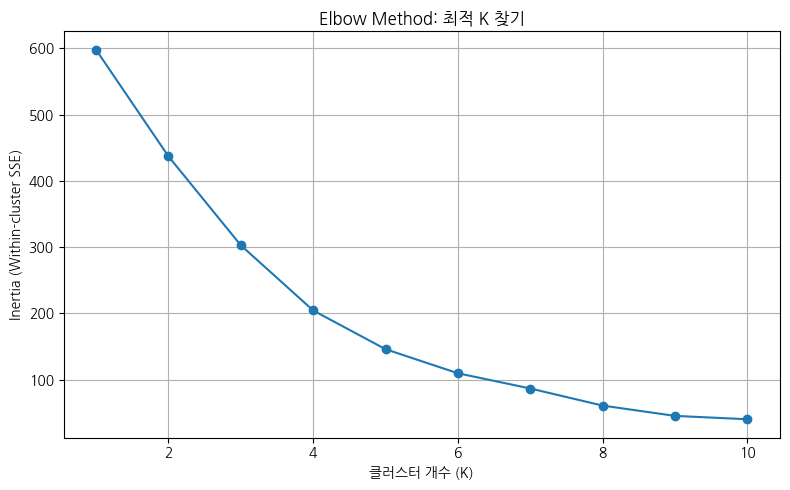

In [54]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method: 최적 K 찾기')
plt.xlabel('클러스터 개수 (K)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.grid(True)
plt.tight_layout()
plt.show()


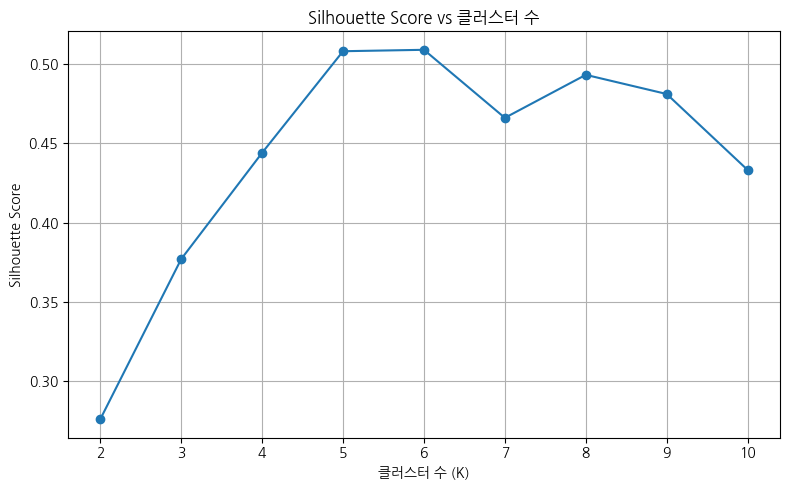

In [55]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled)
    score = silhouette_score(scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score vs 클러스터 수')
plt.xlabel('클러스터 수 (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()


In [68]:
from sklearn.cluster import KMeans

# 클러스터 개수 선택 (예: 3개)
kmeans = KMeans(n_clusters=5, random_state=42)
features['cluster'] = kmeans.fit_predict(scaled)


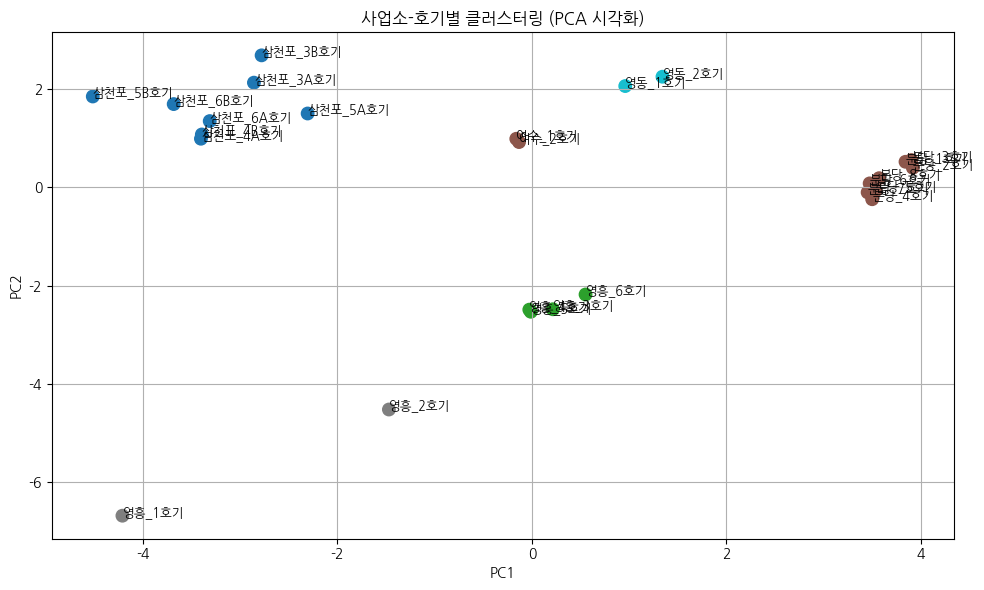

In [69]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled)

plt.figure(figsize=(10, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=features['cluster'], cmap='tab10', s=80)
for i, name in enumerate(features.index):
    plt.text(reduced[i, 0], reduced[i, 1], name, fontsize=9)

plt.title("사업소-호기별 클러스터링 (PCA 시각화)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
features[['cluster']].value_counts().sort_index()

cluster
0          15
1           4
2           7
Name: count, dtype: int64

In [ ]:
# features: 클러스터링 결과가 저장된 DataFrame (index가 '사업소_호기')
for cluster_id in sorted(features['cluster'].unique()):
    print(f"\n📦 클러스터 {cluster_id}에 포함된 사업소_호기들:")
    print("----------------------------------------")
    members = features[features['cluster'] == cluster_id].index.tolist()
    for name in members:
        print(" -", name)



       



📦 클러스터 0에 포함된 사업소_호기들:
----------------------------------------
 - 삼천포_3B호기

📦 클러스터 1에 포함된 사업소_호기들:
----------------------------------------
 - 영흥_3호기
 - 영흥_4호기
 - 영흥_5호기
 - 영흥_6호기

📦 클러스터 2에 포함된 사업소_호기들:
----------------------------------------
 - 분당_1호기
 - 분당_2호기
 - 분당_3호기
 - 분당_4호기
 - 분당_5호기
 - 분당_6호기
 - 분당_7호기
 - 분당_8호기

📦 클러스터 3에 포함된 사업소_호기들:
----------------------------------------
 - 영흥_1호기
 - 영흥_2호기

📦 클러스터 4에 포함된 사업소_호기들:
----------------------------------------
 - 영동_1호기
 - 영동_2호기

📦 클러스터 5에 포함된 사업소_호기들:
----------------------------------------
 - 삼천포_3A호기
 - 삼천포_4A호기
 - 삼천포_4B호기
 - 삼천포_5A호기
 - 삼천포_5B호기
 - 삼천포_6A호기
 - 삼천포_6B호기
 - 여수_1호기
 - 여수_2호기


In [41]:
features.reset_index()

,series_id,NOX_mean,NOX_std,NOX_min,NOX_max,유량_mean,유량_std,유량_min,유량_max,온도_mean,온도_std,온도_min,온도_max,산소_mean,산소_std,산소_min,산소_max,cluster
0,분당_1호기,5.468024,17.813520,0.00,470.88,22097.886168,26165.200520,0.0,67752.30,72.172340,39.458495,9.22,129.41,18.751748,2.348615,13.782506,21.11,2
1,분당_2호기,2.796314,3.643907,0.00,39.15,9312.601996,17952.263643,0.0,65867.42,50.557853,31.998325,12.37,146.34,19.923731,1.715277,13.782506,21.13,2
2,분당_3호기,4.311812,4.168146,0.00,41.33,21630.122068,26059.789209,0.0,70376.85,71.056986,39.550607,11.56,126.29,18.794254,2.352090,13.782506,21.01,2
3,분당_4호기,2.469844,2.983356,0.00,31.13,8241.328644,18009.437263,0.0,73865.55,43.000479,26.687929,8.07,113.76,20.059655,1.562469,13.782506,21.03,2
4,분당_5호기,3.683123,4.335877,0.00,36.88,17711.094781,28130.286967,0.0,103655.13,53.766941,33.826250,4.70,122.30,19.492575,2.064413,13.782506,21.00,2
5,분당_6호기,8.151691,6.251332,0.00,33.01,28160.965826,26953.926500,0.0,74433.97,69.439522,34.893196,0.05,131.48,17.642090,3.868229,0.000000,21.02,0
6,분당_7호기,3.409981,4.307684,0.00,40.37,19641.429684,25639.284281,0.0,73949.39,53.261615,33.306561,1.88,125.63,18.491734,3.871324,0.000000,20.91,0
7,분당_8호기,7.734153,6.409601,0.00,38.62,27370.619684,27325.338403,0.0,73081.71,68.393735,35.932181,2.16,134.00,17.758232,3.907800,0.000000,20.87,0
8,삼천포_3A호기,50.112052,62.935132,0.01,929.27,50797.985308,32007.905526,0.0,89952.57,77.338413,31.542918,2.77,106.35,10.136306,6.120313,3.010000,21.13,0
9,삼천포_3B호기,32.422093,38.865298,0.00,951.98,46164.826361,30130.484475,0.0,96124.11,79.481710,33.296816,0.99,110.77,10.031395,6.176705,3.010000,21.17,0
